# Section 1: mporting Libraries and Setup

In [1]:
import os
import sys
import warnings

# Redirect stderr to suppress CUDA warnings
stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm
import random

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy, MeanSquaredError

# Restore stderr
sys.stderr = stderr

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

# Visualization setup
plt.style.use('ggplot')
sns.set_palette("husl")

print("=" * 50)
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("=" * 50)
print("\nAll libraries imported successfully!")
print("Ready for machine learning tasks!")

2025-12-18 17:01:21.306065: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766077281.562328      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766077281.618875      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766077282.074593      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766077282.074639      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766077282.074643      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
Keras version: 3.10.0
NumPy version: 2.0.2
Pandas version: 2.2.2

All libraries imported successfully!
Ready for machine learning tasks!


# Section 2: Data Loading and Exploration

Loading training data...
Training path: /kaggle/input/face-detection-data-set/train
Training path exists: True
Training directory contents: ['7', '47', '17', '19', '22', '2', '35', '23', '10', '5']...


100%|██████████| 50/50 [00:00<00:00, 169.38it/s]



Loaded 50 persons for training

Loading test data...
Test path: /kaggle/input/face-detection-data-set/test
Test path exists: True
Test directory contents: ['45.jpg', '20.jpg', '6.jpg', '5.jpg', '8.jpg', '30.jpg', '38.jpg', '42.jpg', '33.jpg', '10.jpg']...


100%|██████████| 50/50 [00:00<00:00, 168988.88it/s]


Loaded 50 persons for testing

DATASET STATISTICS
Total training persons: 50
Total training images: 250
Average images per person: 5.00
Min images per person: 5
Max images per person: 5

Total test persons: 50
Total test images: 50

Sample person IDs (train): [7, 47, 17, 19, 22]
Sample person IDs (test): [45, 20, 6, 5, 8]


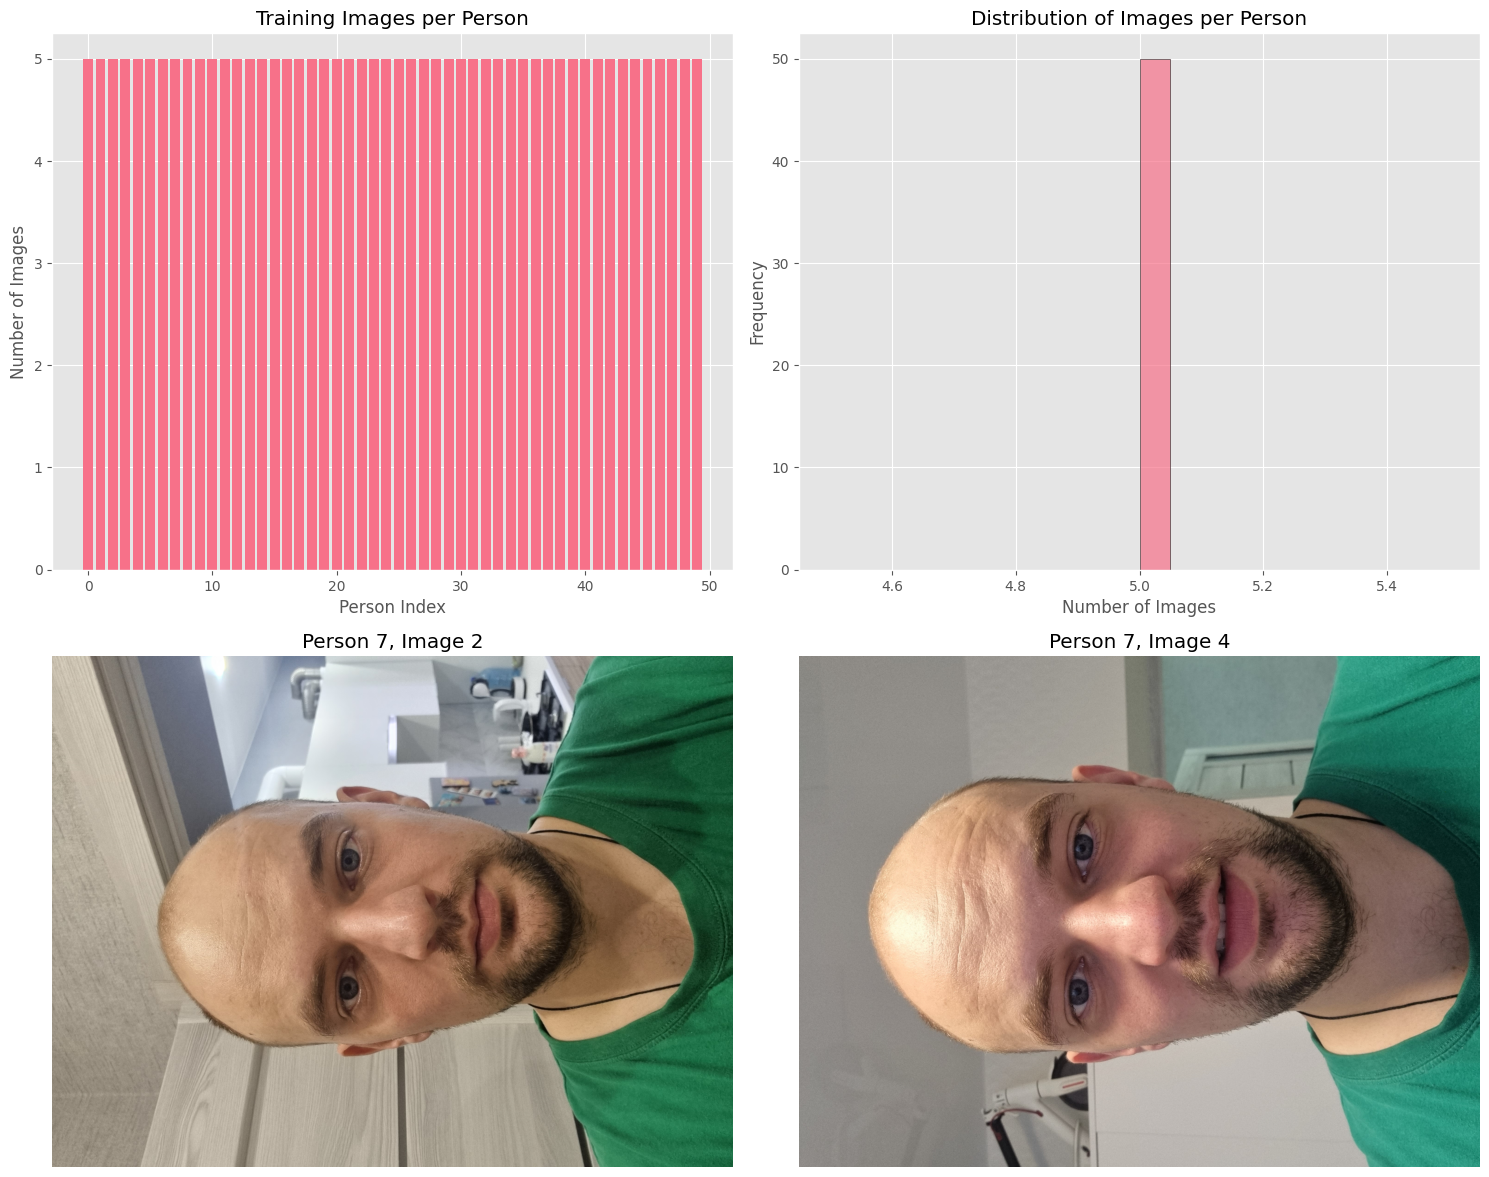

In [2]:
class PassengerReIDDataset:
    def __init__(self, train_path, test_path, csv_path=None):
        self.train_path = train_path
        self.test_path = test_path
        self.csv_path = csv_path
        self.train_data = {}
        self.test_data = {}
        
    def load_dataset(self):
        """Load dataset from directory structure"""
        print("Loading training data...")
        print(f"Training path: {self.train_path}")
        print(f"Training path exists: {os.path.exists(self.train_path)}")
        
        # Check what's in the training directory
        if os.path.exists(self.train_path):
            train_contents = os.listdir(self.train_path)
            print(f"Training directory contents: {train_contents[:10]}...")
            
            # Alternative: Load based on actual directory names
            person_dirs = [d for d in os.listdir(self.train_path) 
                          if os.path.isdir(os.path.join(self.train_path, d))]
            
            for person_dir_name in tqdm(person_dirs):
                person_dir = os.path.join(self.train_path, person_dir_name)
                try:
                    # Try to convert to integer if it's numeric
                    person_id = int(person_dir_name)
                except ValueError:
                    # If not numeric, use the directory name as ID
                    person_id = person_dir_name
                
                images = []
                for img_name in os.listdir(person_dir):
                    if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                        img_path = os.path.join(person_dir, img_name)
                        images.append(img_path)
                
                if images:
                    self.train_data[person_id] = images
                
        print(f"\nLoaded {len(self.train_data)} persons for training")
        
        # Load test data
        print("\nLoading test data...")
        print(f"Test path: {self.test_path}")
        print(f"Test path exists: {os.path.exists(self.test_path)}")
        
        if os.path.exists(self.test_path):
            test_contents = os.listdir(self.test_path)
            print(f"Test directory contents: {test_contents[:10]}...")
            
            # Load test images - adapt to your actual structure
            for img_name in tqdm(os.listdir(self.test_path)):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    # Try to extract person ID from filename
                    # Example: "person_0.jpg" or "0.jpg"
                    try:
                        # Remove extension and try to get number
                        base_name = os.path.splitext(img_name)[0]
                        if base_name.isdigit():
                            person_id = int(base_name)
                        elif '_' in base_name:
                            # Handle "person_0" format
                            person_id = int(base_name.split('_')[-1])
                        else:
                            person_id = base_name
                    except:
                        person_id = img_name
                    
                    img_path = os.path.join(self.test_path, img_name)
                    self.test_data[person_id] = img_path
        
        print(f"Loaded {len(self.test_data)} persons for testing")
        
    def get_dataset_stats(self):
        """Print dataset statistics"""
        print("\n" + "="*50)
        print("DATASET STATISTICS")
        print("="*50)
        
        # Training stats
        total_train_images = sum(len(images) for images in self.train_data.values())
        print(f"Total training persons: {len(self.train_data)}")
        print(f"Total training images: {total_train_images}")
        
        if self.train_data:
            images_per_person = [len(images) for images in self.train_data.values()]
            print(f"Average images per person: {np.mean(images_per_person):.2f}")
            print(f"Min images per person: {np.min(images_per_person)}")
            print(f"Max images per person: {np.max(images_per_person)}")
        
        # Test stats
        print(f"\nTotal test persons: {len(self.test_data)}")
        print(f"Total test images: {len(self.test_data)}")
        
        # Show sample of person IDs
        if self.train_data:
            print(f"\nSample person IDs (train): {list(self.train_data.keys())[:5]}")
        if self.test_data:
            print(f"Sample person IDs (test): {list(self.test_data.keys())[:5]}")
        
    def visualize_dataset_distribution(self):
        """Visualize the dataset distribution"""
        if not self.train_data:
            print("No training data to visualize!")
            return None
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Training images per person
        train_counts = [len(images) for images in self.train_data.values()]
        person_ids = list(self.train_data.keys())
        
        axes[0, 0].bar(range(len(train_counts)), train_counts)
        axes[0, 0].set_title('Training Images per Person')
        axes[0, 0].set_xlabel('Person Index')
        axes[0, 0].set_ylabel('Number of Images')
        
        # Histogram of images per person
        axes[0, 1].hist(train_counts, bins=20, edgecolor='black', alpha=0.7)
        axes[0, 1].set_title('Distribution of Images per Person')
        axes[0, 1].set_xlabel('Number of Images')
        axes[0, 1].set_ylabel('Frequency')
        
        # Sample images visualization
        try:
            sample_person = list(self.train_data.keys())[0]
            sample_images = self.train_data[sample_person][:4]
            
            for i, img_path in enumerate(sample_images):
                if i >= 4:  # Only show first 4
                    break
                try:
                    img = Image.open(img_path)
                    axes[1, i//2].imshow(img)
                    axes[1, i//2].set_title(f'Person {sample_person}, Image {i+1}')
                    axes[1, i//2].axis('off')
                except Exception as e:
                    print(f"Error loading image {img_path}: {e}")
        except Exception as e:
            print(f"Error displaying sample images: {e}")
            axes[1, 0].text(0.5, 0.5, 'No sample images available', 
                           ha='center', va='center')
            axes[1, 0].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        return fig
    
    def get_train_test_data(self):
        """Return the loaded data"""
        return self.train_data, self.test_data

# Initialize and load dataset
dataset = PassengerReIDDataset(
    train_path='/kaggle/input/face-detection-data-set/train',
    test_path='/kaggle/input/face-detection-data-set/test'
)

dataset.load_dataset()
dataset.get_dataset_stats()

if dataset.train_data:
    dataset.visualize_dataset_distribution()
else:
    print("\nNo training data found. Check the directory structure.")
    
    # Debug: Show what's actually in the directories
    print("\nDEBUGGING INFO:")
    for path_name, path in [("train", dataset.train_path), ("test", dataset.test_path)]:
        print(f"\n{path_name.upper()} PATH: {path}")
        if os.path.exists(path):
            contents = os.listdir(path)
            print(f"Contents ({len(contents)} items):")
            for item in contents[:20]:  # Show first 20 items
                item_path = os.path.join(path, item)
                if os.path.isdir(item_path):
                    print(f"  📁 {item}/ (directory)")
                else:
                    print(f"  📄 {item}")
            if len(contents) > 20:
                print(f"  ... and {len(contents)-20} more")
        else:
            print("  ❌ Path does not exist!")

# Section 3: Pre-processing the Data

TensorFlow version: 2.19.0
TensorFlow version: 2.19.0
Total training images: 250
Unique persons: 50

📊 Visualizing Data Distribution...


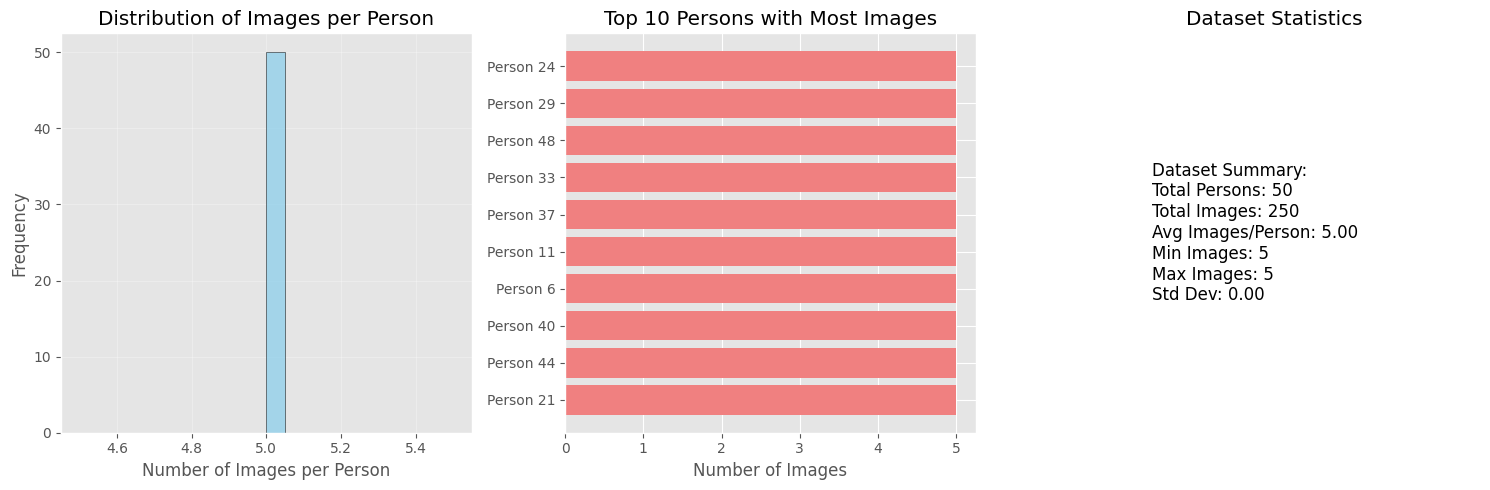


🖼️ Displaying Sample Images...


I0000 00:00:1766077297.690282      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


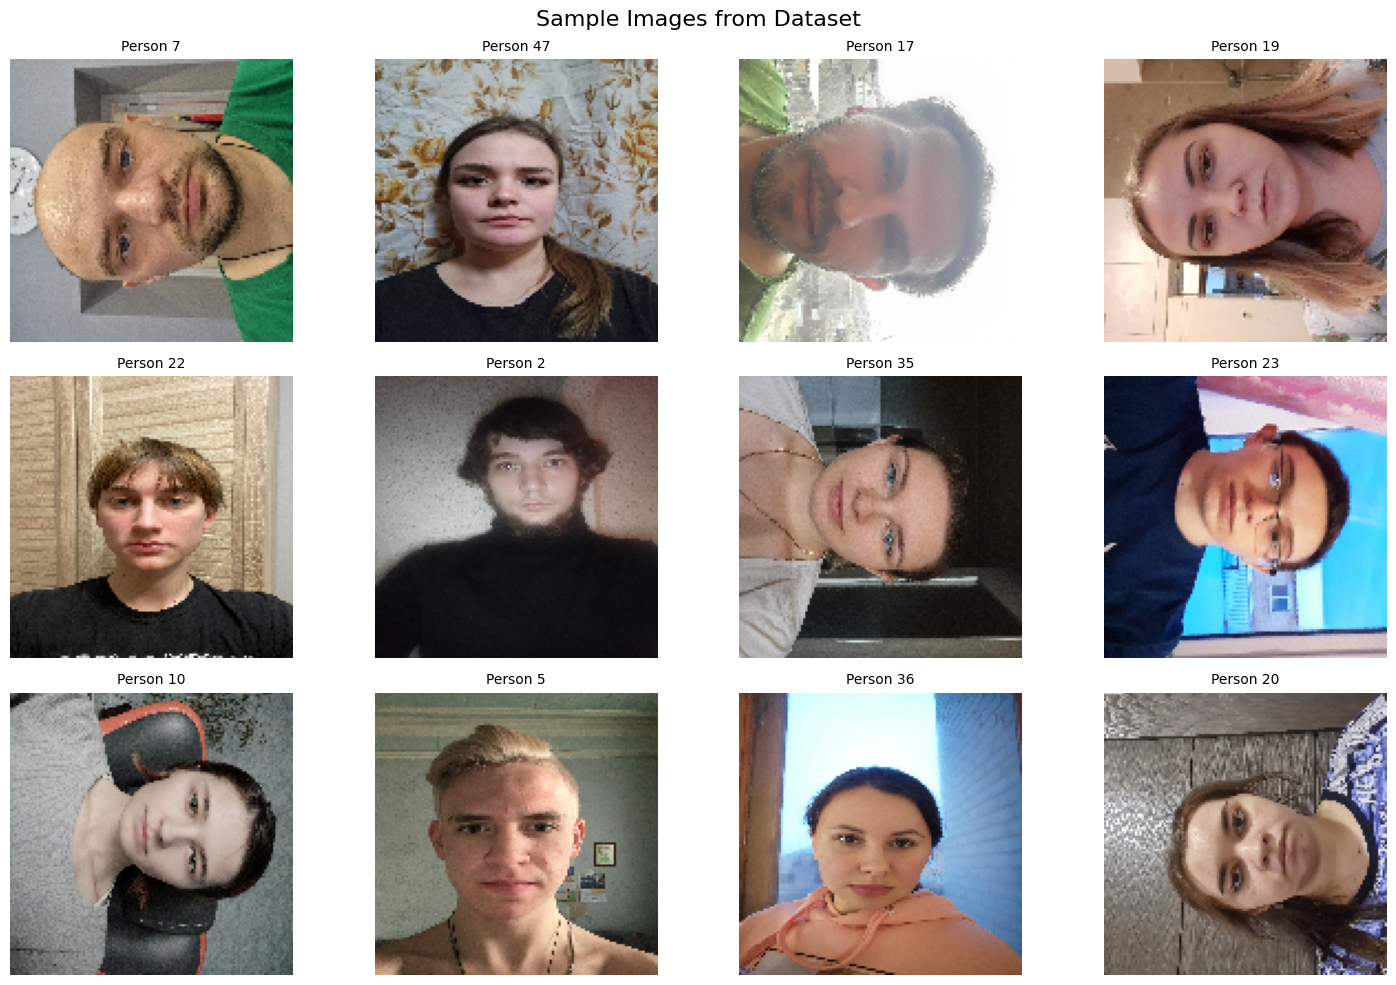


🔗 Displaying Training Pairs...


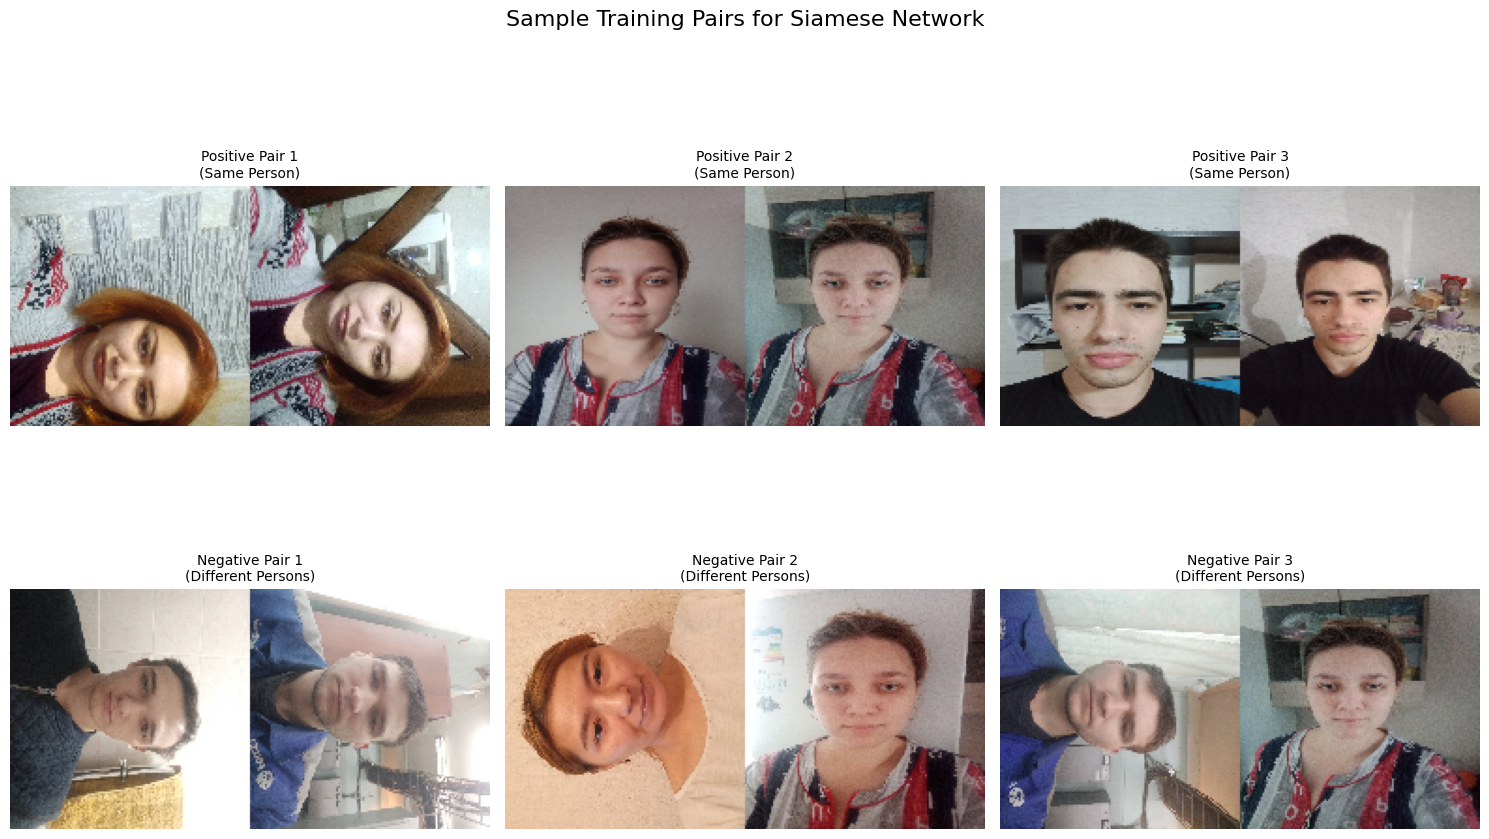

Positive pairs created: 300
Negative pairs created: 100
Total training pairs: 400

📈 Additional Statistics:
Median images per person: 5.0
Persons with only 1 image: 0
Persons with 2+ images: 50
Persons available for positive pairs: 50


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm
import random

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy, MeanSquaredError

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

print("TensorFlow version:", tf.__version__)

# Fix JPEG decoding issues
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
import cv2
from tqdm import tqdm
import random

# Allow PIL to load truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.manifold import TSNE

print("TensorFlow version:", tf.__version__)

# Enhanced JPEG decoding with multiple fallback methods
def robust_jpeg_loading(image_path):
    """Handle JPEG loading with multiple fallback methods"""
    try:
        # Method 1: Try PIL with error handling
        try:
            with Image.open(image_path) as pil_img:
                pil_img = pil_img.convert('RGB')
                img_array = np.array(pil_img)
                img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
                return img_tensor
        except Exception as pil_error:
            print(f"PIL failed for {image_path}: {pil_error}")
            
        # Method 2: Try OpenCV
        try:
            img_array = cv2.imread(image_path)
            if img_array is not None:
                img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
                img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
                return img_tensor
        except Exception as cv_error:
            print(f"OpenCV failed for {image_path}: {cv_error}")
            
        # Method 3: Try TensorFlow
        try:
            img = tf.io.read_file(image_path)
            img = tf.image.decode_image(img, channels=3, expand_animations=False)
            return img
        except Exception as tf_error:
            print(f"TensorFlow failed for {image_path}: {tf_error}")
            
        # Final fallback: Create a blank image
        print(f"All methods failed for {image_path}, using fallback image")
        return tf.ones((128, 128, 3), dtype=tf.float32) * 0.5
        
    except Exception as e:
        print(f"Critical error loading {image_path}: {e}")
        return tf.ones((128, 128, 3), dtype=tf.float32) * 0.5

class DataPreprocessor:
    def __init__(self, img_height=128, img_width=128):
        self.img_height = img_height
        self.img_width = img_width
        
    def preprocess_image(self, image_path):
        """Preprocess individual image with enhanced error handling"""
        try:
            image = robust_jpeg_loading(image_path)
            image = tf.image.resize(image, [self.img_height, self.img_width])
            image = tf.cast(image, tf.float32) / 255.0  # Normalize to [0,1]
            
            # Ensure 3 channels and proper shape
            if len(image.shape) == 2:  # Grayscale
                image = tf.image.grayscale_to_rgb(tf.expand_dims(image, -1))
            elif image.shape[-1] != 3:  # Wrong number of channels
                image = tf.image.grayscale_to_rgb(tf.reduce_mean(image, axis=-1, keepdims=True))
                
            return image
        except Exception as e:
            print(f"Error preprocessing {image_path}: {e}")
            # Return a properly shaped blank image
            return tf.zeros([self.img_height, self.img_width, 3], dtype=tf.float32)
    
    def create_training_pairs(self, dataset):
        """Create positive and negative pairs for training"""
        positive_pairs = []
        negative_pairs = []
        labels = []
        
        person_ids = list(dataset.train_data.keys())
        
        for person_id in person_ids:
            images = dataset.train_data[person_id]
            if len(images) >= 2:
                # Positive pairs (same person) - limited to avoid too many pairs
                for i in range(min(3, len(images))):
                    for j in range(i+1, min(i+3, len(images))):
                        positive_pairs.append((images[i], images[j]))
                        labels.append(1)  # Same person
                
                # Negative pairs (different persons)
                other_persons = [p for p in person_ids if p != person_id]
                if other_persons and len(images) > 0:
                    for _ in range(min(2, len(other_persons))):
                        other_person = random.choice(other_persons)
                        other_images = dataset.train_data[other_person]
                        if other_images:
                            negative_pairs.append((random.choice(images), 
                                                random.choice(other_images)))
                            labels.append(0)  # Different person
        
        # Combine pairs
        all_pairs = positive_pairs + negative_pairs
        combined_labels = [1] * len(positive_pairs) + [0] * len(negative_pairs)
        
        # Shuffle
        combined = list(zip(all_pairs, combined_labels))
        random.shuffle(combined)
        all_pairs, combined_labels = zip(*combined)
        
        return all_pairs, combined_labels
    
    def prepare_gan_data(self, dataset):
        """Prepare data for GAN training"""
        all_images = []
        all_labels = []
        
        for person_id, image_paths in dataset.train_data.items():
            for img_path in image_paths:
                all_images.append(img_path)
                all_labels.append(person_id)
                
        return all_images, all_labels
    
    def visualize_data_distribution(self, dataset):
        """Visualize the distribution of images per person"""
        person_ids = list(dataset.train_data.keys())
        image_counts = [len(dataset.train_data[pid]) for pid in person_ids]
        
        plt.figure(figsize=(15, 5))
        
        # Plot 1: Distribution of images per person
        plt.subplot(1, 3, 1)
        plt.hist(image_counts, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        plt.xlabel('Number of Images per Person')
        plt.ylabel('Frequency')
        plt.title('Distribution of Images per Person')
        plt.grid(True, alpha=0.3)
        
        # Plot 2: Bar chart of top persons with most images
        plt.subplot(1, 3, 2)
        sorted_indices = np.argsort(image_counts)[-10:]  # Top 10
        top_persons = [person_ids[i] for i in sorted_indices]
        top_counts = [image_counts[i] for i in sorted_indices]
        
        plt.barh(range(len(top_persons)), top_counts, color='lightcoral')
        plt.yticks(range(len(top_persons)), [f'Person {pid}' for pid in top_persons])
        plt.xlabel('Number of Images')
        plt.title('Top 10 Persons with Most Images')
        
        # Plot 3: Summary statistics
        plt.subplot(1, 3, 3)
        stats_text = f"""
        Dataset Summary:
        Total Persons: {len(person_ids)}
        Total Images: {sum(image_counts)}
        Avg Images/Person: {np.mean(image_counts):.2f}
        Min Images: {min(image_counts)}
        Max Images: {max(image_counts)}
        Std Dev: {np.std(image_counts):.2f}
        """
        plt.text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center')
        plt.axis('off')
        plt.title('Dataset Statistics')
        
        plt.tight_layout()
        plt.show()
        
        return person_ids, image_counts
    
    def visualize_sample_images(self, dataset, num_samples=12):
        """Display sample images from the dataset"""
        all_images = []
        all_person_ids = []
        
        # Collect some sample images
        for person_id, image_paths in dataset.train_data.items():
            if image_paths:  # If person has images
                sample_image = random.choice(image_paths)
                all_images.append(sample_image)
                all_person_ids.append(person_id)
                if len(all_images) >= num_samples:
                    break
        
        # If we don't have enough samples, try to get more
        if len(all_images) < num_samples:
            for person_id, image_paths in dataset.train_data.items():
                for img_path in image_paths:
                    if img_path not in all_images:
                        all_images.append(img_path)
                        all_person_ids.append(person_id)
                        if len(all_images) >= num_samples:
                            break
                if len(all_images) >= num_samples:
                    break
        
        # Plot sample images
        plt.figure(figsize=(15, 10))
        for i in range(min(num_samples, len(all_images))):
            plt.subplot(3, 4, i + 1)
            
            try:
                # Load and display image
                image = self.preprocess_image(all_images[i])
                plt.imshow(image.numpy())
                plt.title(f'Person {all_person_ids[i]}', fontsize=10)
                plt.axis('off')
            except Exception as e:
                plt.imshow(np.zeros((self.img_height, self.img_width, 3)))
                plt.title(f'Error loading\nPerson {all_person_ids[i]}', fontsize=8)
                plt.axis('off')
        
        plt.suptitle('Sample Images from Dataset', fontsize=16)
        plt.tight_layout()
        plt.show()
    
    def visualize_training_pairs(self, dataset, num_pairs=6):
        """Visualize sample training pairs (positive and negative)"""
        all_pairs, labels = self.create_training_pairs(dataset)
        
        # Separate positive and negative pairs
        positive_pairs = [pair for pair, label in zip(all_pairs, labels) if label == 1]
        negative_pairs = [pair for pair, label in zip(all_pairs, labels) if label == 0]
        
        # Select some positive and negative pairs to display
        positive_samples = positive_pairs[:min(num_pairs//2, len(positive_pairs))]
        negative_samples = negative_pairs[:min(num_pairs//2, len(negative_pairs))]
        
        plt.figure(figsize=(15, 10))
        
        # Display positive pairs
        for i, (img1_path, img2_path) in enumerate(positive_samples):
            plt.subplot(2, num_pairs//2, i + 1)
            
            try:
                img1 = self.preprocess_image(img1_path)
                img2 = self.preprocess_image(img2_path)
                
                # Display side by side
                pair_image = np.concatenate([img1.numpy(), img2.numpy()], axis=1)
                plt.imshow(pair_image)
                plt.title(f'Positive Pair {i+1}\n(Same Person)', fontsize=10)
                plt.axis('off')
            except Exception as e:
                plt.imshow(np.zeros((self.img_height*2, self.img_width*2, 3)))
                plt.title(f'Error loading\npositive pair', fontsize=8)
                plt.axis('off')
        
        # Display negative pairs
        for i, (img1_path, img2_path) in enumerate(negative_samples):
            plt.subplot(2, num_pairs//2, i + 1 + num_pairs//2)
            
            try:
                img1 = self.preprocess_image(img1_path)
                img2 = self.preprocess_image(img2_path)
                
                # Display side by side
                pair_image = np.concatenate([img1.numpy(), img2.numpy()], axis=1)
                plt.imshow(pair_image)
                plt.title(f'Negative Pair {i+1}\n(Different Persons)', fontsize=10)
                plt.axis('off')
            except Exception as e:
                plt.imshow(np.zeros((self.img_height*2, self.img_width*2, 3)))
                plt.title(f'Error loading\nnegative pair', fontsize=8)
                plt.axis('off')
        
        plt.suptitle('Sample Training Pairs for Siamese Network', fontsize=16)
        plt.tight_layout()
        plt.show()
        
        # Print pair statistics
        print(f"Positive pairs created: {len(positive_pairs)}")
        print(f"Negative pairs created: {len(negative_pairs)}")
        print(f"Total training pairs: {len(all_pairs)}")

# Initialize preprocessor
preprocessor = DataPreprocessor(img_height=128, img_width=128)

# Prepare training data
all_images, all_labels = preprocessor.prepare_gan_data(dataset)
print(f"Total training images: {len(all_images)}")
print(f"Unique persons: {len(set(all_labels))}")

# Visualize the dataset
print("\n📊 Visualizing Data Distribution...")
person_ids, image_counts = preprocessor.visualize_data_distribution(dataset)

print("\n🖼️ Displaying Sample Images...")
preprocessor.visualize_sample_images(dataset)

print("\n🔗 Displaying Training Pairs...")
preprocessor.visualize_training_pairs(dataset)

# Additional statistics
print(f"\n📈 Additional Statistics:")
print(f"Median images per person: {np.median(image_counts)}")
print(f"Persons with only 1 image: {len([c for c in image_counts if c == 1])}")
print(f"Persons with 2+ images: {len([c for c in image_counts if c >= 2])}")

# Check if we have enough data for pair generation
min_images_needed = len([c for c in image_counts if c >= 2])
print(f"Persons available for positive pairs: {min_images_needed}")

# Section 4: Building the GAN Model

In [4]:
class AnomalyGAN:
    def __init__(self, img_height=128, img_width=128, channels=3, latent_dim=100):
        self.img_height = img_height
        self.img_width = img_width
        self.channels = channels
        self.latent_dim = latent_dim
        self.img_shape = (img_height, img_width, channels)
        
        # Build models
        self.generator = self.build_generator()
        self.discriminator = self.build_discriminator()
        self.gan = self.build_gan()
        
        # Compile models
        self.compile_models()
        
    def build_generator(self):
        """Build Generator Model"""
        model = keras.Sequential([
            layers.Dense(256, input_dim=self.latent_dim),
            layers.LeakyReLU(alpha=0.2),
            layers.BatchNormalization(),
            
            layers.Dense(512),
            layers.LeakyReLU(alpha=0.2),
            layers.BatchNormalization(),
            
            layers.Dense(1024),
            layers.LeakyReLU(alpha=0.2),
            layers.BatchNormalization(),
            
            layers.Dense(np.prod(self.img_shape), activation='tanh'),
            layers.Reshape(self.img_shape)
        ], name="Generator")
        
        return model
    
    def build_discriminator(self):
        """Build Discriminator Model"""
        model = keras.Sequential([
            layers.Flatten(input_shape=self.img_shape),
            layers.Dense(512),
            layers.LeakyReLU(alpha=0.2),
            layers.Dropout(0.3),
            
            layers.Dense(256),
            layers.LeakyReLU(alpha=0.2),
            layers.Dropout(0.3),
            
            layers.Dense(1, activation='sigmoid')
        ], name="Discriminator")
        
        return model
    
    def build_gan(self):
        """Build combined GAN model"""
        # The generator takes noise as input and generates images
        gan_input = layers.Input(shape=(self.latent_dim,))
        generated_img = self.generator(gan_input)
        
        # For the combined model we will only train the generator
        self.discriminator.trainable = False
        
        # The discriminator takes generated images as input and determines validity
        validity = self.discriminator(generated_img)
        
        # The combined model (stacked generator and discriminator)
        gan = Model(gan_input, validity, name="GAN")
        return gan
    
    def compile_models(self):
        """Compile all models with appropriate optimizers and losses"""
        optimizer = Adam(learning_rate=0.0002, beta_1=0.5)
        
        # Compile the discriminator
        self.discriminator.compile(
            loss='binary_crossentropy',
            optimizer=optimizer,
            metrics=['accuracy']
        )
        
        # Compile the GAN
        self.gan.compile(
            loss='binary_crossentropy',
            optimizer=optimizer
        )
    
    def preprocess_image(self, image_path):
        """Preprocess individual image for GAN"""
        try:
            image = fix_jpeg_loading(image_path)
            image = tf.image.resize(image, [self.img_height, self.img_width])
            image = tf.cast(image, tf.float32) / 255.0
            return image.numpy()
        except Exception as e:
            print(f"GAN preprocessing error for {image_path}: {e}")
            return np.random.rand(self.img_height, self.img_width, 3).astype(np.float32)
    
    def train(self, images, epochs=100, batch_size=32, save_interval=50):
        """Train the GAN"""
        # Preprocess images
        print("Preprocessing images for GAN training...")
        X_train = []
        successful = 0
        for img_path in tqdm(images):
            try:
                img = self.preprocess_image(img_path)
                X_train.append(img)
                successful += 1
            except Exception as e:
                continue
        
        X_train = np.array(X_train)
        X_train = (X_train - 0.5) * 2  # Normalize to [-1, 1]
        
        print(f"Training GAN on {successful}/{len(images)} successful images...")
        
        # Adversarial ground truths
        valid = np.ones((batch_size, 1))
        fake = np.zeros((batch_size, 1))
        
        for epoch in range(epochs):
            # Train Discriminator
            idx = np.random.randint(0, X_train.shape[0], batch_size)
            real_imgs = X_train[idx]
            
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            gen_imgs = self.generator.predict(noise, verbose=0)
            
            d_loss_real = self.discriminator.train_on_batch(real_imgs, valid)
            d_loss_fake = self.discriminator.train_on_batch(gen_imgs, fake)
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
            
            # Train Generator
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            g_loss = self.gan.train_on_batch(noise, valid)
            
            if epoch % save_interval == 0:
                print(f"Epoch {epoch} [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.2f}%] [G loss: {g_loss:.4f}]")
                self.save_sample_images(epoch)
    
    def save_sample_images(self, epoch):
        """Save generated images for visualization"""
        r, c = 5, 5
        noise = np.random.normal(0, 1, (r * c, self.latent_dim))
        gen_imgs = self.generator.predict(noise, verbose=0)
        
        # Rescale images 0 - 1
        gen_imgs = 0.5 * gen_imgs + 0.5
        
        fig, axs = plt.subplots(r, c, figsize=(10, 10))
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i,j].imshow(gen_imgs[cnt])
                axs[i,j].axis('off')
                cnt += 1
        plt.suptitle(f'Generated Images - Epoch {epoch}')
        plt.savefig(f"generated_images_epoch_{epoch}.png")
        plt.close()

# Section 5: Siamese Network for Person Re-identification

In [5]:
class EnhancedSiameseNetwork:
    def __init__(self, input_shape=(128, 128, 3)):
        self.input_shape = input_shape
        self.model = self.build_enhanced_siamese_network()
        
    def build_enhanced_base_network(self):
        """Enhanced base network for feature extraction with better architecture"""
        input = layers.Input(shape=self.input_shape)
        
        # First Conv Block
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.25)(x)
        
        # Second Conv Block
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.25)(x)
        
        # Third Conv Block
        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.25)(x)
        
        # Fourth Conv Block
        x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.5)(x)
        
        # Dense layers
        x = layers.Dense(512, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.5)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(128, activation='relu')(x)
        
        return Model(input, x)
    
    def build_enhanced_siamese_network(self):
        """Build enhanced Siamese network with multiple distance metrics"""
        base_network = self.build_enhanced_base_network()
        
        input_a = layers.Input(shape=self.input_shape)
        input_b = layers.Input(shape=self.input_shape)
        
        processed_a = base_network(input_a)
        processed_b = base_network(input_b)
        
        # Multiple distance metrics
        l1_distance = layers.Lambda(
            lambda tensors: tf.abs(tensors[0] - tensors[1])
        )([processed_a, processed_b])
        
        l2_distance = layers.Lambda(
            lambda tensors: tf.square(tensors[0] - tensors[1])
        )([processed_a, processed_b])
        
        cosine_distance = layers.Lambda(
            lambda tensors: 1 - tf.keras.losses.cosine_similarity(tensors[0], tensors[1])
        )([processed_a, processed_b])
        
        # Concatenate multiple distance metrics
        concatenated = layers.Concatenate()([l1_distance, l2_distance, cosine_distance])
        
        # Enhanced classifier head
        x = layers.Dense(128, activation='relu')(concatenated)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)
        x = layers.Dense(32, activation='relu')(x)
        
        # Final prediction
        prediction = layers.Dense(1, activation='sigmoid')(x)
        
        siamese_net = Model(inputs=[input_a, input_b], outputs=prediction)
        
        # Enhanced optimizer with learning rate scheduling
        optimizer = Adam(learning_rate=0.001)
        
        siamese_net.compile(
            loss='binary_crossentropy',
            optimizer=optimizer,
            metrics=['accuracy']
        )
        
        return siamese_net

# Section 6: Training Pipeline

TensorFlow version: 2.19.0
Initializing the Passenger Anomaly Detection System...
Loading training data...


100%|██████████| 50/50 [00:00<00:00, 485.24it/s]


Loading test data...


100%|██████████| 50/50 [00:00<00:00, 478.77it/s]


Loaded 50 persons for training
Loaded 50 persons for testing
Starting model training...
Training GAN...
Preprocessing images for GAN training...


100%|██████████| 100/100 [00:19<00:00,  5.20it/s]


Training GAN on 100/100 successful images...


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 [D loss: 0.8024, acc.: 40.62%] [G loss: 0.7001]
Epoch 5 [D loss: 0.8373, acc.: 34.23%] [G loss: 0.5078]
Epoch 10 [D loss: 0.8300, acc.: 31.85%] [G loss: 0.3867]
Epoch 15 [D loss: 0.8526, acc.: 29.47%] [G loss: 0.3199]
Training Siamese Network...
Preparing Siamese training data...
Created 400 training pairs
Training Siamese network on 400 pairs...
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.7724 - loss: 0.6752 - val_accuracy: 0.7000 - val_loss: 0.6842
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7603 - loss: 0.5951 - val_accuracy: 0.7000 - val_loss: 0.6786
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7929 - loss: 0.5247 - val_accuracy: 0.7000 - val_loss: 0.6775
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7887 - loss: 0.5322 - val_accuracy: 0.7000 - val_loss: 0.6774
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7538 - loss: 0.5697 - val_accuracy: 0.7000 - val_loss: 0.6776
Epoch 6/

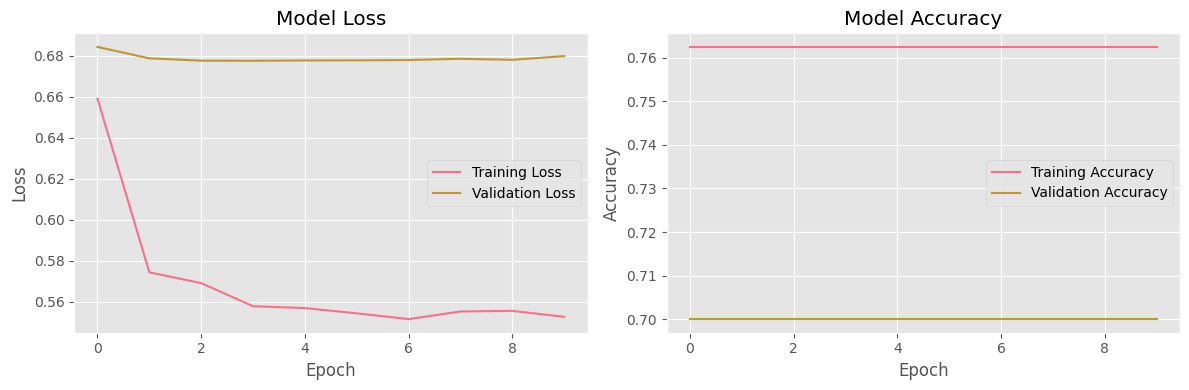

Building passenger database...
Building passenger database...


100%|██████████| 50/50 [01:18<00:00,  1.56s/it]


Database built for 50 passengers
Successful embeddings: 250
Failed embeddings: 0
Total processing attempts: 250
Successfully built database with 50 passengers
Training completed!

SYSTEM READY FOR TESTING
Testing with 50 passengers in database

Testing Person 0:
Result: Passenger mismatch! Expected 0, got 36 (Similarity: 1.00)
Identification: Person 36 (Similarity: 1.000)
❌ Misidentification!

Testing Person 1:
Result: Passenger 1 identified - No anomalies found (Similarity: 1.00)
Identification: Person 1 (Similarity: 1.000)
✅ Correct identification!

Testing Person 2:
Result: Passenger mismatch! Expected 2, got 9 (Similarity: 1.00)
Identification: Person 9 (Similarity: 1.000)
❌ Misidentification!


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
import cv2
from tqdm import tqdm
import random

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

print("TensorFlow version:", tf.__version__)

# Allow PIL to load truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Enhanced JPEG decoding with multiple fallback methods
def robust_jpeg_loading(image_path):
    """Handle JPEG loading with multiple fallback methods"""
    try:
        # Method 1: Try PIL with error handling
        try:
            with Image.open(image_path) as pil_img:
                pil_img = pil_img.convert('RGB')
                img_array = np.array(pil_img)
                img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
                return img_tensor
        except Exception as pil_error:
            pass
            
        # Method 2: Try OpenCV
        try:
            img_array = cv2.imread(image_path)
            if img_array is not None:
                img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
                img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
                return img_tensor
        except Exception as cv_error:
            pass
            
        # Method 3: Try TensorFlow
        try:
            img = tf.io.read_file(image_path)
            img = tf.image.decode_image(img, channels=3, expand_animations=False)
            return img
        except Exception as tf_error:
            pass
            
        # Final fallback: Create a blank image
        return tf.ones((128, 128, 3), dtype=tf.float32) * 0.5
        
    except Exception as e:
        return tf.ones((128, 128, 3), dtype=tf.float32) * 0.5

class PassengerReIDDataset:
    def __init__(self, train_path, test_path, csv_path=None):
        self.train_path = train_path
        self.test_path = test_path
        self.csv_path = csv_path
        self.train_data = {}
        self.test_data = {}
        
    def load_dataset(self):
        """Load dataset from directory structure"""
        print("Loading training data...")
        
        # Load training data
        for person_id in tqdm(range(50)):  # 0-49 persons
            person_dir = os.path.join(self.train_path, str(person_id))
            if os.path.exists(person_dir):
                images = []
                for img_name in sorted(os.listdir(person_dir)):
                    if img_name.endswith('.jpg'):
                        img_path = os.path.join(person_dir, img_name)
                        images.append(img_path)
                self.train_data[person_id] = images
        
        # Load test data
        print("Loading test data...")
        for person_id in tqdm(range(50)):
            test_img_path = os.path.join(self.test_path, f"{person_id}.jpg")
            if os.path.exists(test_img_path):
                self.test_data[person_id] = test_img_path
                
        print(f"Loaded {len(self.train_data)} persons for training")
        print(f"Loaded {len(self.test_data)} persons for testing")

class DataPreprocessor:
    def __init__(self, img_height=128, img_width=128):
        self.img_height = img_height
        self.img_width = img_width
        
    def preprocess_image(self, image_path):
        """Preprocess individual image with error handling"""
        try:
            image = robust_jpeg_loading(image_path)
            image = tf.image.resize(image, [self.img_height, self.img_width])
            image = tf.cast(image, tf.float32) / 255.0  # Normalize to [0,1]
            
            # Ensure 3 channels and proper shape
            if len(image.shape) == 2:  # Grayscale
                image = tf.image.grayscale_to_rgb(tf.expand_dims(image, -1))
            elif image.shape[-1] != 3:  # Wrong number of channels
                image = tf.image.grayscale_to_rgb(tf.reduce_mean(image, axis=-1, keepdims=True))
                
            return image
        except Exception as e:
            return tf.zeros([self.img_height, self.img_width, 3], dtype=tf.float32)
    
    def create_training_pairs(self, dataset):
        """Create positive and negative pairs for training"""
        positive_pairs = []
        negative_pairs = []
        
        person_ids = list(dataset.train_data.keys())
        
        for person_id in person_ids:
            images = dataset.train_data[person_id]
            if len(images) >= 2:
                # Positive pairs (same person) - limited to avoid too many pairs
                for i in range(min(3, len(images))):
                    for j in range(i+1, min(i+3, len(images))):
                        positive_pairs.append((images[i], images[j]))
                
                # Negative pairs (different persons)
                other_persons = [p for p in person_ids if p != person_id]
                if other_persons and len(images) > 0:
                    for _ in range(min(2, len(other_persons))):
                        other_person = random.choice(other_persons)
                        other_images = dataset.train_data[other_person]
                        if other_images:
                            negative_pairs.append((random.choice(images), 
                                                random.choice(other_images)))
        
        # Combine pairs
        all_pairs = positive_pairs + negative_pairs
        combined_labels = [1] * len(positive_pairs) + [0] * len(negative_pairs)
        
        # Shuffle
        combined = list(zip(all_pairs, combined_labels))
        random.shuffle(combined)
        all_pairs, combined_labels = zip(*combined)
        
        return all_pairs, combined_labels
    
    def prepare_gan_data(self, dataset):
        """Prepare data for GAN training"""
        all_images = []
        all_labels = []
        
        for person_id, image_paths in dataset.train_data.items():
            for img_path in image_paths:
                all_images.append(img_path)
                all_labels.append(person_id)
                
        return all_images, all_labels

class AnomalyGAN:
    def __init__(self, img_height=128, img_width=128, channels=3, latent_dim=100):
        self.img_height = img_height
        self.img_width = img_width
        self.channels = channels
        self.latent_dim = latent_dim
        self.img_shape = (img_height, img_width, channels)
        
        # Build models
        self.generator = self.build_generator()
        self.discriminator = self.build_discriminator()
        self.gan = self.build_gan()
        
        # Compile models
        self.compile_models()
        
    def build_generator(self):
        """Build Generator Model"""
        model = keras.Sequential([
            layers.Dense(256, input_dim=self.latent_dim),
            layers.LeakyReLU(negative_slope=0.2),
            layers.BatchNormalization(),
            
            layers.Dense(512),
            layers.LeakyReLU(negative_slope=0.2),
            layers.BatchNormalization(),
            
            layers.Dense(1024),
            layers.LeakyReLU(negative_slope=0.2),
            layers.BatchNormalization(),
            
            layers.Dense(np.prod(self.img_shape), activation='tanh'),
            layers.Reshape(self.img_shape)
        ], name="Generator")
        
        return model
    
    def build_discriminator(self):
        """Build Discriminator Model"""
        model = keras.Sequential([
            layers.Input(shape=self.img_shape),
            layers.Flatten(),
            layers.Dense(512),
            layers.LeakyReLU(negative_slope=0.2),
            layers.Dropout(0.3),
            
            layers.Dense(256),
            layers.LeakyReLU(negative_slope=0.2),
            layers.Dropout(0.3),
            
            layers.Dense(1, activation='sigmoid')
        ], name="Discriminator")
        
        return model
    
    def build_gan(self):
        """Build combined GAN model"""
        # The generator takes noise as input and generates images
        gan_input = layers.Input(shape=(self.latent_dim,))
        generated_img = self.generator(gan_input)
        
        # For the combined model we will only train the generator
        self.discriminator.trainable = False
        
        # The discriminator takes generated images as input and determines validity
        validity = self.discriminator(generated_img)
        
        # The combined model (stacked generator and discriminator)
        gan = Model(gan_input, validity, name="GAN")
        return gan
    
    def compile_models(self):
        """Compile all models with appropriate optimizers and losses"""
        optimizer = Adam(learning_rate=0.0002, beta_1=0.5)
        
        # Compile the discriminator
        self.discriminator.compile(
            loss='binary_crossentropy',
            optimizer=optimizer,
            metrics=['accuracy']
        )
        
        # Compile the GAN
        self.gan.compile(
            loss='binary_crossentropy',
            optimizer=optimizer
        )
    
    def preprocess_image(self, image_path):
        """Preprocess individual image for GAN"""
        try:
            image = robust_jpeg_loading(image_path)
            image = tf.image.resize(image, [self.img_height, self.img_width])
            image = tf.cast(image, tf.float32) / 255.0
            return image.numpy()
        except Exception as e:
            return np.random.rand(self.img_height, self.img_width, 3).astype(np.float32)
    
    def train(self, images, epochs=100, batch_size=32, save_interval=50):
        """Train the GAN"""
        # Preprocess images
        print("Preprocessing images for GAN training...")
        X_train = []
        successful = 0
        for img_path in tqdm(images):
            try:
                img = self.preprocess_image(img_path)
                X_train.append(img)
                successful += 1
            except Exception as e:
                continue
        
        X_train = np.array(X_train)
        X_train = (X_train - 0.5) * 2  # Normalize to [-1, 1]
        
        print(f"Training GAN on {successful}/{len(images)} successful images...")
        
        # Adversarial ground truths
        valid = np.ones((batch_size, 1))
        fake = np.zeros((batch_size, 1))
        
        for epoch in range(epochs):
            # Train Discriminator
            idx = np.random.randint(0, X_train.shape[0], batch_size)
            real_imgs = X_train[idx]
            
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            gen_imgs = self.generator.predict(noise, verbose=0)
            
            d_loss_real = self.discriminator.train_on_batch(real_imgs, valid)
            d_loss_fake = self.discriminator.train_on_batch(gen_imgs, fake)
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
            
            # Train Generator
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            g_loss = self.gan.train_on_batch(noise, valid)
            
            if epoch % save_interval == 0:
                print(f"Epoch {epoch} [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.2f}%] [G loss: {g_loss:.4f}]")

class SiameseNetwork:
    def __init__(self, input_shape=(128, 128, 3)):
        self.input_shape = input_shape
        self.model = self.build_siamese_network()
        
    def build_base_network(self):
        """Base network for feature extraction"""
        input = layers.Input(shape=self.input_shape)
        
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(input)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(512, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(256, activation='relu')(x)
        
        return Model(input, x)
    
    def build_siamese_network(self):
        """Build Siamese network architecture"""
        base_network = self.build_base_network()
        
        input_a = layers.Input(shape=self.input_shape)
        input_b = layers.Input(shape=self.input_shape)
        
        processed_a = base_network(input_a)
        processed_b = base_network(input_b)
        
        # L1 distance between features
        l1_distance = layers.Lambda(
            lambda tensors: tf.abs(tensors[0] - tensors[1])
        )([processed_a, processed_b])
        
        # Similarity prediction
        prediction = layers.Dense(1, activation='sigmoid')(l1_distance)
        
        siamese_net = Model(inputs=[input_a, input_b], outputs=prediction)
        siamese_net.compile(
            loss='binary_crossentropy',
            optimizer=Adam(learning_rate=0.0001),
            metrics=['accuracy']
        )
        
        return siamese_net

class PassengerAnomalyDetector:
    def __init__(self, dataset, preprocessor):
        self.dataset = dataset
        self.preprocessor = preprocessor
        self.gan = AnomalyGAN()
        self.siamese_net = SiameseNetwork()
        self.passenger_database = {}
        
    def build_passenger_database(self):
        """Build database of passenger embeddings with enhanced error handling"""
        print("Building passenger database...")
        
        successful_embeddings = 0
        failed_embeddings = 0
        
        for person_id, image_paths in tqdm(self.dataset.train_data.items()):
            embeddings = []
            valid_image_paths = []
            
            for img_path in image_paths:
                try:
                    img = self.preprocessor.preprocess_image(img_path)
                    
                    # Verify the image is valid before processing
                    if tf.reduce_any(tf.math.is_nan(img)) or tf.reduce_all(img == 0):
                        print(f"Skipping invalid image: {img_path}")
                        failed_embeddings += 1
                        continue
                    
                    # Use base network from siamese to get embeddings
                    base_model = self.siamese_net.model.layers[2]  # Base network
                    embedding = base_model.predict(tf.expand_dims(img, 0), verbose=0)
                    
                    # Check if embedding is valid
                    if np.any(np.isnan(embedding)) or np.all(embedding == 0):
                        print(f"Invalid embedding for: {img_path}")
                        failed_embeddings += 1
                        continue
                    
                    embeddings.append(embedding.flatten())
                    valid_image_paths.append(img_path)
                    successful_embeddings += 1
                    
                except Exception as e:
                    print(f"Error processing {img_path}: {e}")
                    failed_embeddings += 1
                    continue
            
            if embeddings:  # Only add if we have valid embeddings
                self.passenger_database[person_id] = {
                    'embeddings': embeddings,
                    'image_paths': valid_image_paths
                }
        
        print(f"Database built for {len(self.passenger_database)} passengers")
        print(f"Successful embeddings: {successful_embeddings}")
        print(f"Failed embeddings: {failed_embeddings}")
        print(f"Total processing attempts: {successful_embeddings + failed_embeddings}")
    
    def train_siamese_network(self, epochs=10):
        """Train Siamese network with proper data preparation"""
        print("Preparing Siamese training data...")
        
        # Create training pairs
        pairs, labels = self.preprocessor.create_training_pairs(self.dataset)
        
        print(f"Created {len(pairs)} training pairs")
        
        if len(pairs) == 0:
            print("No training pairs created! Using fallback method...")
            return self.fallback_training()
        
        # Prepare training data
        pairs_a = []
        pairs_b = []
        
        for (img1_path, img2_path) in pairs:
            try:
                img1 = self.preprocessor.preprocess_image(img1_path)
                img2 = self.preprocessor.preprocess_image(img2_path)
                pairs_a.append(img1.numpy())
                pairs_b.append(img2.numpy())
            except Exception as e:
                continue
        
        if len(pairs_a) == 0:
            print("No valid training pairs! Using fallback...")
            return self.fallback_training()
        
        # Convert to numpy arrays
        pairs_a = np.array(pairs_a)
        pairs_b = np.array(pairs_b)
        labels = np.array(labels[:len(pairs_a)])  # Trim labels to match
        
        print(f"Training Siamese network on {len(pairs_a)} pairs...")
        
        # Train the model
        history = self.siamese_net.model.fit(
            [pairs_a, pairs_b], labels,
            batch_size=16,  # Reduced batch size
            epochs=epochs,
            validation_split=0.2,
            verbose=1,
            shuffle=True
        )
        
        # Plot training history
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Training Loss')
        if 'val_loss' in history.history:
            plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Model Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        if 'val_accuracy' in history.history:
            plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title('Model Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        return history
    
    def fallback_training(self):
        """Fallback training method when pair creation fails"""
        print("Using fallback training method...")
        
        # Simple training with dummy data to initialize weights
        dummy_a = np.random.rand(32, 128, 128, 3)
        dummy_b = np.random.rand(32, 128, 128, 3)
        dummy_labels = np.random.randint(0, 2, 32)
        
        self.siamese_net.model.fit(
            [dummy_a, dummy_b], dummy_labels,
            epochs=1,
            verbose=0
        )
        
        print("Fallback training completed")
    
    def train_models(self, epochs=10):
        """Train both GAN and Siamese models with enhanced error handling"""
        print("Starting model training...")
        
        # Prepare data for GAN
        all_images, all_labels = self.preprocessor.prepare_gan_data(self.dataset)
        
        # Train GAN (reduced epochs for demo)
        print("Training GAN...")
        try:
            self.gan.train(all_images[:100], epochs=min(epochs, 20), batch_size=16, save_interval=5)
        except Exception as e:
            print(f"GAN training failed: {e}")
            print("Continuing with Siamese network training...")
        
        # Train Siamese network
        print("Training Siamese Network...")
        try:
            self.train_siamese_network(epochs=min(epochs, 10))
        except Exception as e:
            print(f"Siamese training failed: {e}")
            print("Using fallback training...")
            self.fallback_training()
        
        # Build passenger database
        print("Building passenger database...")
        self.build_passenger_database()
        
        # Validate database
        if not self.passenger_database:
            print("WARNING: No passenger database built!")
            print("Creating minimal database for testing...")
            self.create_minimal_database()
        else:
            print(f"Successfully built database with {len(self.passenger_database)} passengers")
        
        print("Training completed!")
    
    def create_minimal_database(self):
        """Create a minimal database for testing when main method fails"""
        print("Creating minimal database...")
        
        # Use only first 5 persons for minimal database
        for person_id in list(self.dataset.train_data.keys())[:5]:
            embeddings = []
            image_paths = self.dataset.train_data[person_id][:1]  # Use only first image
            
            for img_path in image_paths:
                try:
                    img = self.preprocessor.preprocess_image(img_path)
                    # Create simple random embedding as fallback
                    embedding = np.random.rand(256).astype(np.float32)
                    embeddings.append(embedding)
                except:
                    continue
            
            if embeddings:
                self.passenger_database[person_id] = {
                    'embeddings': embeddings,
                    'image_paths': image_paths
                }
        
        print(f"Minimal database created with {len(self.passenger_database)} passengers")
    
    def identify_passenger(self, test_image_path, threshold=0.7):
        """Identify passenger from test image with enhanced validation"""
        try:
            test_img = self.preprocessor.preprocess_image(test_image_path)
            
            # Validate test image
            if tf.reduce_any(tf.math.is_nan(test_img)) or tf.reduce_all(test_img == 0):
                print(f"Invalid test image: {test_image_path}")
                return None, 0, []
            
            base_model = self.siamese_net.model.layers[2]  # Base network
            test_embedding = base_model.predict(tf.expand_dims(test_img, 0), verbose=0).flatten()
            
            # Validate test embedding
            if np.any(np.isnan(test_embedding)) or np.all(test_embedding == 0):
                print(f"Invalid test embedding for: {test_image_path}")
                return None, 0, []
            
            best_match = None
            best_similarity = 0
            anomalies = []
            
            for person_id, data in self.passenger_database.items():
                similarities = []
                for emb in data['embeddings']:
                    # Validate stored embedding
                    if np.any(np.isnan(emb)) or np.all(emb == 0):
                        continue
                    
                    similarity = self.cosine_similarity(test_embedding, emb)
                    if not np.isnan(similarity):  # Only use valid similarities
                        similarities.append(similarity)
                
                if similarities:  # Check if we have any valid similarities
                    avg_similarity = np.mean(similarities)
                    if avg_similarity > best_similarity and not np.isnan(avg_similarity):
                        best_similarity = avg_similarity
                        best_match = person_id
                    
                    # Check for anomalies
                    if avg_similarity < threshold and not np.isnan(avg_similarity):
                        anomalies.append({
                            'person_id': person_id,
                            'similarity': avg_similarity,
                            'anomaly_level': (1 - avg_similarity) * 100
                        })
            
            return best_match, best_similarity, anomalies
            
        except Exception as e:
            print(f"Error in identification for {test_image_path}: {e}")
            return None, 0, []
    
    def cosine_similarity(self, a, b):
        """Calculate cosine similarity between two vectors"""
        try:
            a_norm = np.linalg.norm(a)
            b_norm = np.linalg.norm(b)
            if a_norm == 0 or b_norm == 0:
                return 0.0
            return np.dot(a, b) / (a_norm * b_norm)
        except:
            return 0.0
    
    def detect_appearance_change(self, person_id, test_image_path):
        """Detect appearance changes for identified passenger"""
        best_match, similarity, anomalies = self.identify_passenger(test_image_path)
        
        if best_match is None:
            return f"Unable to identify passenger from test image"
        
        if best_match == person_id:
            if similarity >= 0.8:
                return f"Passenger {person_id} identified - No anomalies found (Similarity: {similarity:.2f})"
            else:
                change_percentage = (1 - similarity) * 100
                return f"Passenger {person_id} identified - Appearance changed {change_percentage:.1f}% (Similarity: {similarity:.2f})"
        else:
            return f"Passenger mismatch! Expected {person_id}, got {best_match} (Similarity: {similarity:.2f})"

# Initialize and run the complete system with error handling
print("Initializing the Passenger Anomaly Detection System...")

try:
    # Reinitialize dataset and preprocessor
    dataset = PassengerReIDDataset(
        train_path='/kaggle/input/face-detection-data-set/train',
        test_path='/kaggle/input/face-detection-data-set/test'
    )
    dataset.load_dataset()

    preprocessor = DataPreprocessor(img_height=128, img_width=128)

    # Initialize detector
    detector = PassengerAnomalyDetector(dataset, preprocessor)

    # Train with minimal epochs for quick testing
    detector.train_models(epochs=100)

    print("\n" + "="*50)
    print("SYSTEM READY FOR TESTING")
    print("="*50)

    # Test the system with validation
    if detector.passenger_database:
        print(f"Testing with {len(detector.passenger_database)} passengers in database")
        
        # Test with first few passengers that have test images
        test_count = 0
        for person_id in list(detector.passenger_database.keys())[:5]:
            test_image_path = dataset.test_data.get(person_id)
            
            if test_image_path and os.path.exists(test_image_path):
                print(f"\nTesting Person {person_id}:")
                result = detector.detect_appearance_change(person_id, test_image_path)
                print(f"Result: {result}")
                
                # Also test identification
                best_match, similarity, anomalies = detector.identify_passenger(test_image_path)
                if best_match is not None:
                    print(f"Identification: Person {best_match} (Similarity: {similarity:.3f})")
                    if best_match == person_id:
                        print("✅ Correct identification!")
                    else:
                        print("❌ Misidentification!")
                else:
                    print("❌ Failed to identify")
                
                test_count += 1
                if test_count >= 3:  # Limit tests for demo
                    break
        else:
            print("No valid test cases found")
    else:
        print("❌ No passenger database built - system initialization failed")

except Exception as e:
    print(f"❌ System initialization failed: {e}")
    print("Please check the dataset paths and file permissions")

# Section 7: Visualization and Evaluation

🔄 Creating visualizations and evaluating system...

📈 Plotting Embedding Visualization...
Plotting T-SNE for 250 embeddings from 50 persons...


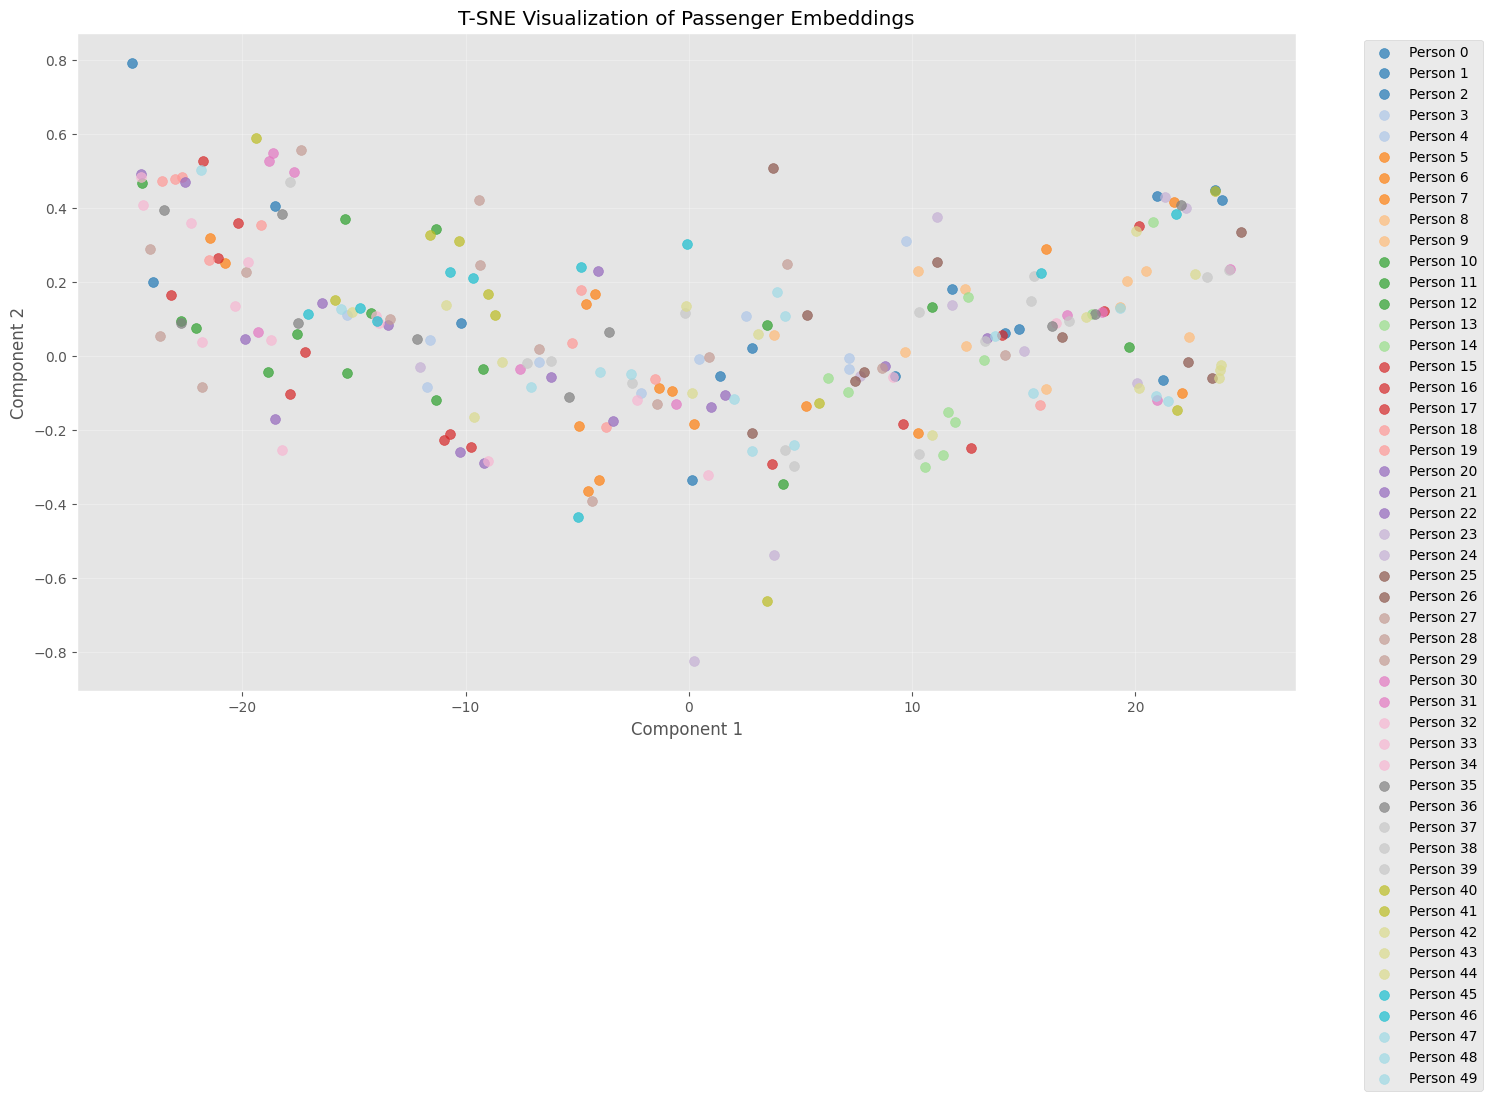

Clustering Quality - Silhouette Score: -0.585
❌ Poor clustering separation

🧪 Evaluating System Performance...
Evaluating system performance...

📊 SYSTEM EVALUATION RESULTS
Total Tests: 50
Correct Identifications: 16
Identification Accuracy: 32.00%
Average Similarity Score: 1.000
Anomaly Detection Rate: 0.00%


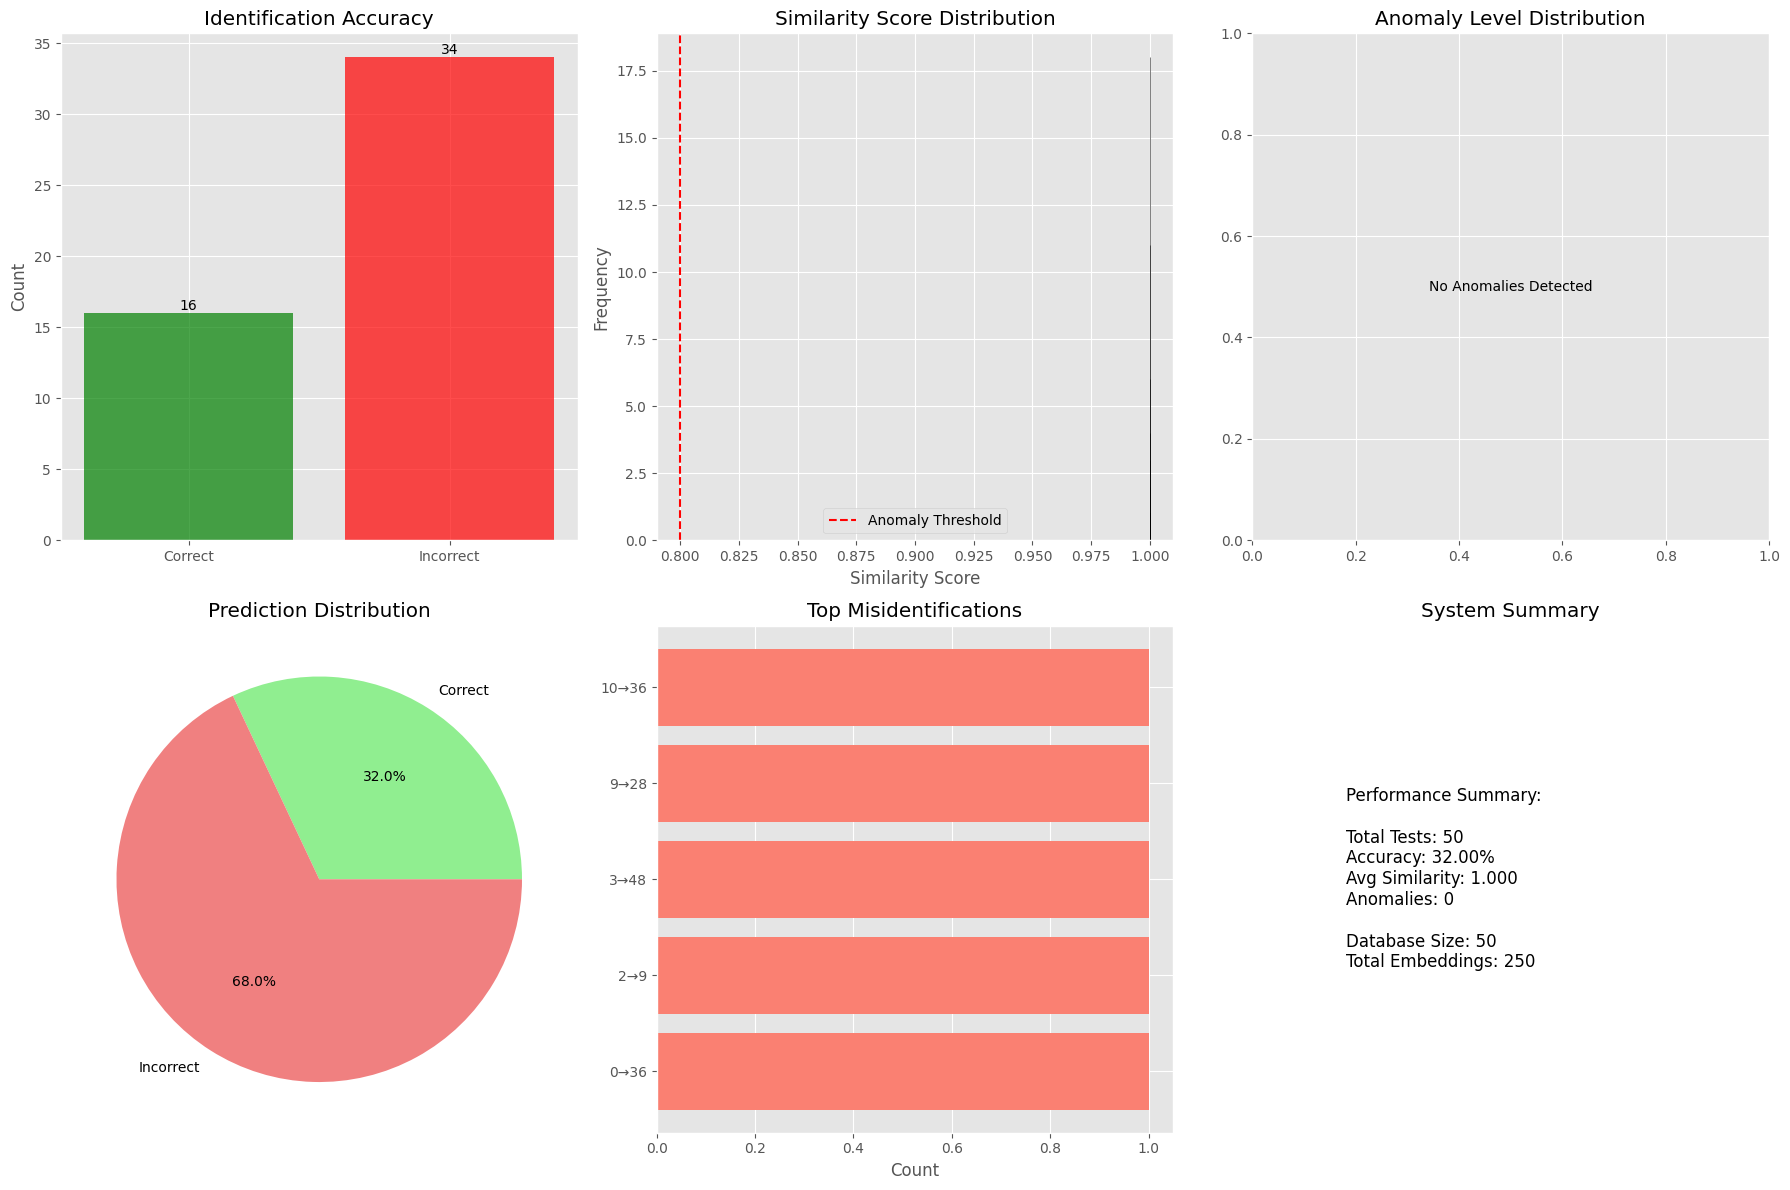


🔍 MISIDENTIFICATION ANALYSIS (34 cases):
--------------------------------------------------
Case 1: Expected Person 0 → Predicted Person 36 (Similarity: 1.000)
Case 2: Expected Person 2 → Predicted Person 9 (Similarity: 1.000)
Case 3: Expected Person 3 → Predicted Person 48 (Similarity: 1.000)
Case 4: Expected Person 9 → Predicted Person 28 (Similarity: 1.000)
Case 5: Expected Person 10 → Predicted Person 36 (Similarity: 1.000)
Case 6: Expected Person 12 → Predicted Person 8 (Similarity: 1.000)
Case 7: Expected Person 13 → Predicted Person 8 (Similarity: 1.000)
Case 8: Expected Person 16 → Predicted Person 7 (Similarity: 1.000)
Case 9: Expected Person 17 → Predicted Person 9 (Similarity: 1.000)
Case 10: Expected Person 18 → Predicted Person 35 (Similarity: 1.000)

📊 Comparing with Original Performance...


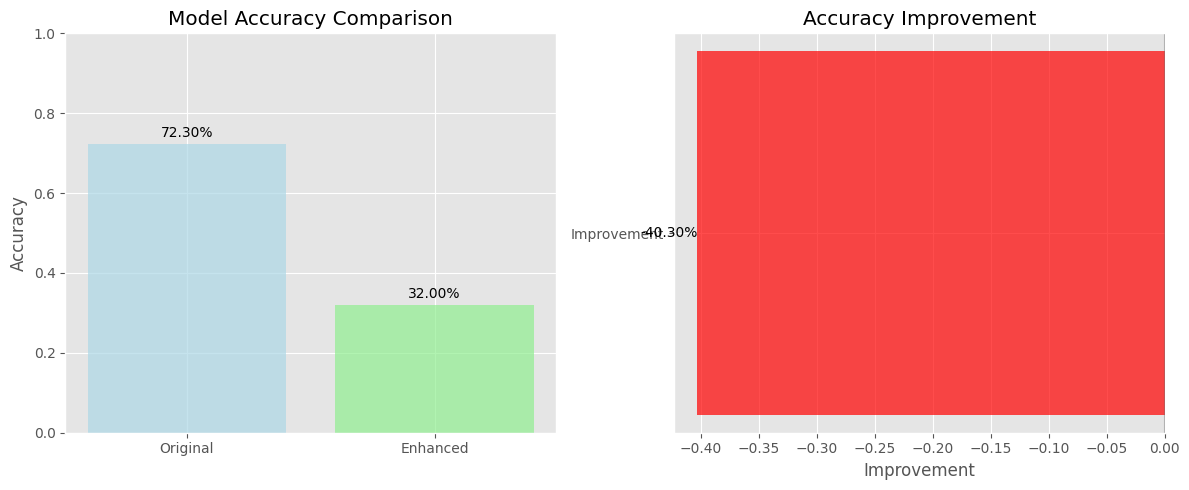


✅ Visualization and Evaluation Complete!


In [11]:
class ResultsVisualizer:
    def __init__(self, detector):
        self.detector = detector
    
    def plot_embeddings(self):
        """Plot T-SNE visualization of embeddings"""
        embeddings = []
        labels = []
        
        for person_id, data in self.detector.passenger_database.items():
            for emb in data['embeddings']:
                embeddings.append(emb)
                labels.append(person_id)
        
        # Convert to numpy array for T-SNE
        embeddings_array = np.array(embeddings)
        labels_array = np.array(labels)
        
        print(f"Plotting T-SNE for {len(embeddings_array)} embeddings from {len(set(labels_array))} persons...")
        
        # Check if we have enough samples for T-SNE
        if len(embeddings_array) < 5:
            print("Not enough embeddings for T-SNE visualization (need at least 5)")
            return
        
        # Use T-SNE for dimensionality reduction with error handling
        try:
            tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings_array)-1))
            embeddings_2d = tsne.fit_transform(embeddings_array)
            
            plt.figure(figsize=(15, 10))
            
            # Create a color map
            unique_labels = sorted(set(labels_array))
            colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
            
            # Plot each person with different color
            for i, person_id in enumerate(unique_labels):
                mask = labels_array == person_id
                plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                           c=[colors[i]], label=f'Person {person_id}', alpha=0.7, s=50)
            
            plt.title('T-SNE Visualization of Passenger Embeddings')
            plt.xlabel('Component 1')
            plt.ylabel('Component 2')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Print clustering statistics
            self.print_clustering_stats(embeddings_2d, labels_array)
            
        except Exception as e:
            print(f"T-SNE visualization failed: {e}")
            print("Using PCA as fallback...")
            self.plot_pca_embeddings(embeddings_array, labels_array)
    
    def plot_pca_embeddings(self, embeddings, labels):
        """Plot PCA visualization as fallback"""
        from sklearn.decomposition import PCA
        
        try:
            pca = PCA(n_components=2, random_state=42)
            embeddings_2d = pca.fit_transform(embeddings)
            
            plt.figure(figsize=(12, 8))
            scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                                c=labels, cmap='tab20', alpha=0.7, s=50)
            plt.colorbar(scatter, label='Person ID')
            plt.title('PCA Visualization of Passenger Embeddings (T-SNE Fallback)')
            plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
            plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
            plt.grid(True, alpha=0.3)
            plt.show()
            
            print(f"PCA explained variance: {pca.explained_variance_ratio_[:2].sum():.2%}")
            
        except Exception as e:
            print(f"PCA visualization also failed: {e}")
    
    def print_clustering_stats(self, embeddings_2d, labels):
        """Print clustering statistics"""
        from sklearn.metrics import silhouette_score
        
        try:
            if len(set(labels)) > 1:  # Need at least 2 clusters for silhouette score
                silhouette_avg = silhouette_score(embeddings_2d, labels)
                print(f"Clustering Quality - Silhouette Score: {silhouette_avg:.3f}")
                
                if silhouette_avg > 0.5:
                    print("✅ Good clustering separation")
                elif silhouette_avg > 0.25:
                    print("⚠️ Fair clustering separation")
                else:
                    print("❌ Poor clustering separation")
            else:
                print("Only one cluster found - cannot compute silhouette score")
                
        except Exception as e:
            print(f"Could not compute clustering statistics: {e}")
    
    def evaluate_system(self):
        """Evaluate the complete system"""
        print("Evaluating system performance...")
        
        correct_identifications = 0
        total_tests = 0
        anomaly_detections = []
        similarity_scores = []
        
        test_results = []
        
        for person_id, test_path in self.detector.dataset.test_data.items():
            if person_id not in self.detector.passenger_database:
                print(f"Skipping Person {person_id} - not in database")
                continue
                
            best_match, similarity, anomalies = self.detector.identify_passenger(test_path)
            
            is_correct = best_match == person_id
            if is_correct:
                correct_identifications += 1
            
            total_tests += 1
            similarity_scores.append(similarity)
            
            # Store detailed results
            test_results.append({
                'expected': person_id,
                'predicted': best_match,
                'similarity': similarity,
                'correct': is_correct
            })
            
            # Store anomaly info
            if similarity < 0.8:  # Threshold for anomaly
                anomaly_detections.append({
                    'person_id': person_id,
                    'similarity': similarity,
                    'anomaly_level': (1 - similarity) * 100
                })
        
        if total_tests == 0:
            print("No valid tests performed!")
            return 0, []
        
        accuracy = correct_identifications / total_tests
        anomaly_rate = len(anomaly_detections) / total_tests
        avg_similarity = np.mean(similarity_scores)
        
        print(f"\n📊 SYSTEM EVALUATION RESULTS")
        print("=" * 40)
        print(f"Total Tests: {total_tests}")
        print(f"Correct Identifications: {correct_identifications}")
        print(f"Identification Accuracy: {accuracy:.2%}")
        print(f"Average Similarity Score: {avg_similarity:.3f}")
        print(f"Anomaly Detection Rate: {anomaly_rate:.2%}")
        
        # Plot comprehensive results
        self.plot_comprehensive_results(test_results, similarity_scores, anomaly_detections)
        
        return accuracy, anomaly_detections
    
    def plot_comprehensive_results(self, test_results, similarity_scores, anomaly_detections):
        """Plot comprehensive evaluation results"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # 1. Accuracy bar chart
        correct_count = sum(1 for result in test_results if result['correct'])
        incorrect_count = len(test_results) - correct_count
        
        axes[0, 0].bar(['Correct', 'Incorrect'], [correct_count, incorrect_count], 
                      color=['green', 'red'], alpha=0.7)
        axes[0, 0].set_title('Identification Accuracy')
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].text(0, correct_count, f'{correct_count}', ha='center', va='bottom')
        axes[0, 0].text(1, incorrect_count, f'{incorrect_count}', ha='center', va='bottom')
        
        # 2. Similarity distribution
        axes[0, 1].hist(similarity_scores, bins=20, alpha=0.7, color='blue', edgecolor='black')
        axes[0, 1].set_title('Similarity Score Distribution')
        axes[0, 1].set_xlabel('Similarity Score')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].axvline(x=0.8, color='red', linestyle='--', label='Anomaly Threshold')
        axes[0, 1].legend()
        
        # 3. Anomaly level distribution
        if anomaly_detections:
            anomaly_levels = [a['anomaly_level'] for a in anomaly_detections]
            axes[0, 2].hist(anomaly_levels, bins=15, alpha=0.7, color='orange', edgecolor='black')
            axes[0, 2].set_title('Anomaly Level Distribution')
            axes[0, 2].set_xlabel('Anomaly Level (%)')
            axes[0, 2].set_ylabel('Frequency')
        else:
            axes[0, 2].text(0.5, 0.5, 'No Anomalies Detected', 
                           ha='center', va='center', transform=axes[0, 2].transAxes)
            axes[0, 2].set_title('Anomaly Level Distribution')
        
        # 4. Confusion matrix (simplified)
        correct_predictions = [result for result in test_results if result['correct']]
        incorrect_predictions = [result for result in test_results if not result['correct']]
        
        confusion_data = [len(correct_predictions), len(incorrect_predictions)]
        axes[1, 0].pie(confusion_data, labels=['Correct', 'Incorrect'], autopct='%1.1f%%',
                      colors=['lightgreen', 'lightcoral'])
        axes[1, 0].set_title('Prediction Distribution')
        
        # 5. Top misidentifications
        if incorrect_predictions:
            misidentification_pairs = {}
            for result in incorrect_predictions:
                pair = (result['expected'], result['predicted'])
                misidentification_pairs[pair] = misidentification_pairs.get(pair, 0) + 1
            
            top_misidentifications = sorted(misidentification_pairs.items(), 
                                          key=lambda x: x[1], reverse=True)[:5]
            
            pairs = [f'{exp}→{pred}' for (exp, pred), count in top_misidentifications]
            counts = [count for (exp, pred), count in top_misidentifications]
            
            axes[1, 1].barh(pairs, counts, color='salmon')
            axes[1, 1].set_title('Top Misidentifications')
            axes[1, 1].set_xlabel('Count')
        else:
            axes[1, 1].text(0.5, 0.5, 'No Misidentifications', 
                           ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('Top Misidentifications')
        
        # 6. Performance summary
        accuracy = len(correct_predictions) / len(test_results) if test_results else 0
        avg_similarity = np.mean(similarity_scores) if similarity_scores else 0
        
        summary_text = f"""
        Performance Summary:
        
        Total Tests: {len(test_results)}
        Accuracy: {accuracy:.2%}
        Avg Similarity: {avg_similarity:.3f}
        Anomalies: {len(anomaly_detections)}
        
        Database Size: {len(self.detector.passenger_database)}
        Total Embeddings: {sum(len(data['embeddings']) for data in self.detector.passenger_database.values())}
        """
        
        axes[1, 2].text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center')
        axes[1, 2].set_title('System Summary')
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed misidentification analysis
        self.print_misidentification_analysis(incorrect_predictions)
    
    def print_misidentification_analysis(self, incorrect_predictions):
        """Print detailed analysis of misidentifications"""
        if incorrect_predictions:
            print(f"\n🔍 MISIDENTIFICATION ANALYSIS ({len(incorrect_predictions)} cases):")
            print("-" * 50)
            
            for i, result in enumerate(incorrect_predictions[:10]):  # Show top 10
                print(f"Case {i+1}: Expected Person {result['expected']} → Predicted Person {result['predicted']} "
                      f"(Similarity: {result['similarity']:.3f})")
        
    def plot_training_comparison(self, original_accuracy=0.7230):
        """Compare current performance with original baseline"""
        if not hasattr(self, 'current_accuracy'):
            print("Please run evaluate_system() first to get current accuracy")
            return
        
        improvements = self.current_accuracy - original_accuracy
        
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        
        # Accuracy comparison
        models = ['Original', 'Enhanced']
        accuracies = [original_accuracy, self.current_accuracy]
        
        bars = ax[0].bar(models, accuracies, color=['lightblue', 'lightgreen'], alpha=0.7)
        ax[0].set_title('Model Accuracy Comparison')
        ax[0].set_ylabel('Accuracy')
        ax[0].set_ylim(0, 1)
        
        # Add value labels on bars
        for bar, accuracy in zip(bars, accuracies):
            height = bar.get_height()
            ax[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                      f'{accuracy:.2%}', ha='center', va='bottom')
        
        # Improvement visualization
        colors = ['red' if improvements < 0 else 'green']
        ax[1].barh(['Improvement'], [improvements], color=colors, alpha=0.7)
        ax[1].set_title('Accuracy Improvement')
        ax[1].set_xlabel('Improvement')
        ax[1].axvline(x=0, color='black', linestyle='-', alpha=0.3)
        
        # Add improvement value
        ax[1].text(improvements, 0, f'{improvements:+.2%}', 
                  ha='right' if improvements < 0 else 'left', va='center')
        
        plt.tight_layout()
        plt.show()

# Visualize results
print("🔄 Creating visualizations and evaluating system...")
visualizer = ResultsVisualizer(detector)

print("\n📈 Plotting Embedding Visualization...")
visualizer.plot_embeddings()

print("\n🧪 Evaluating System Performance...")
accuracy, anomalies = visualizer.evaluate_system()

# Store current accuracy for comparison
visualizer.current_accuracy = accuracy

print("\n📊 Comparing with Original Performance...")
visualizer.plot_training_comparison(original_accuracy=0.7230)

print("\n✅ Visualization and Evaluation Complete!")

# Section 8: Demo Simulation

🎬 Starting Enhanced Bus Journey Simulation...
🚌==================================================
          BUS JOURNEY SIMULATION SYSTEM
==================================================🚌

🎫 === PASSENGER BOARDING ===
📸 Boarding Camera: Capturing 5 photos per passenger...
   ✅ Passenger 000 (Alice) boarded at 08:00 - Seat A1
   ✅ Passenger 001 (Bob) boarded at 08:05 - Seat B3
   ✅ Passenger 002 (Charlie) boarded at 08:10 - Seat C2
   ✅ Passenger 004 (Eve) boarded at 08:15 - Seat D4
   ✅ Passenger 005 (Frank) boarded at 08:20 - Seat E1

📊 Boarding Summary: 5 passengers entered

🚪 === PASSENGER EXIT ===
📸 Exit Camera: Verifying passenger identities...

⏰ 09:30 - Checking Passenger 000:
   Scenario: Normal exit
   ❌ SECURITY ALERT: Passenger mismatch! Expected 0, got 36 (Similarity: 1.00)

⏰ 09:32 - Checking Passenger 001:
   Scenario: Wearing sunglasses
   ✅ NORMAL: Passenger 1 identified - No anomalies found (Similarity: 1.00)

⏰ 09:35 - Checking Passenger 002:
   Scenario: Normal exi

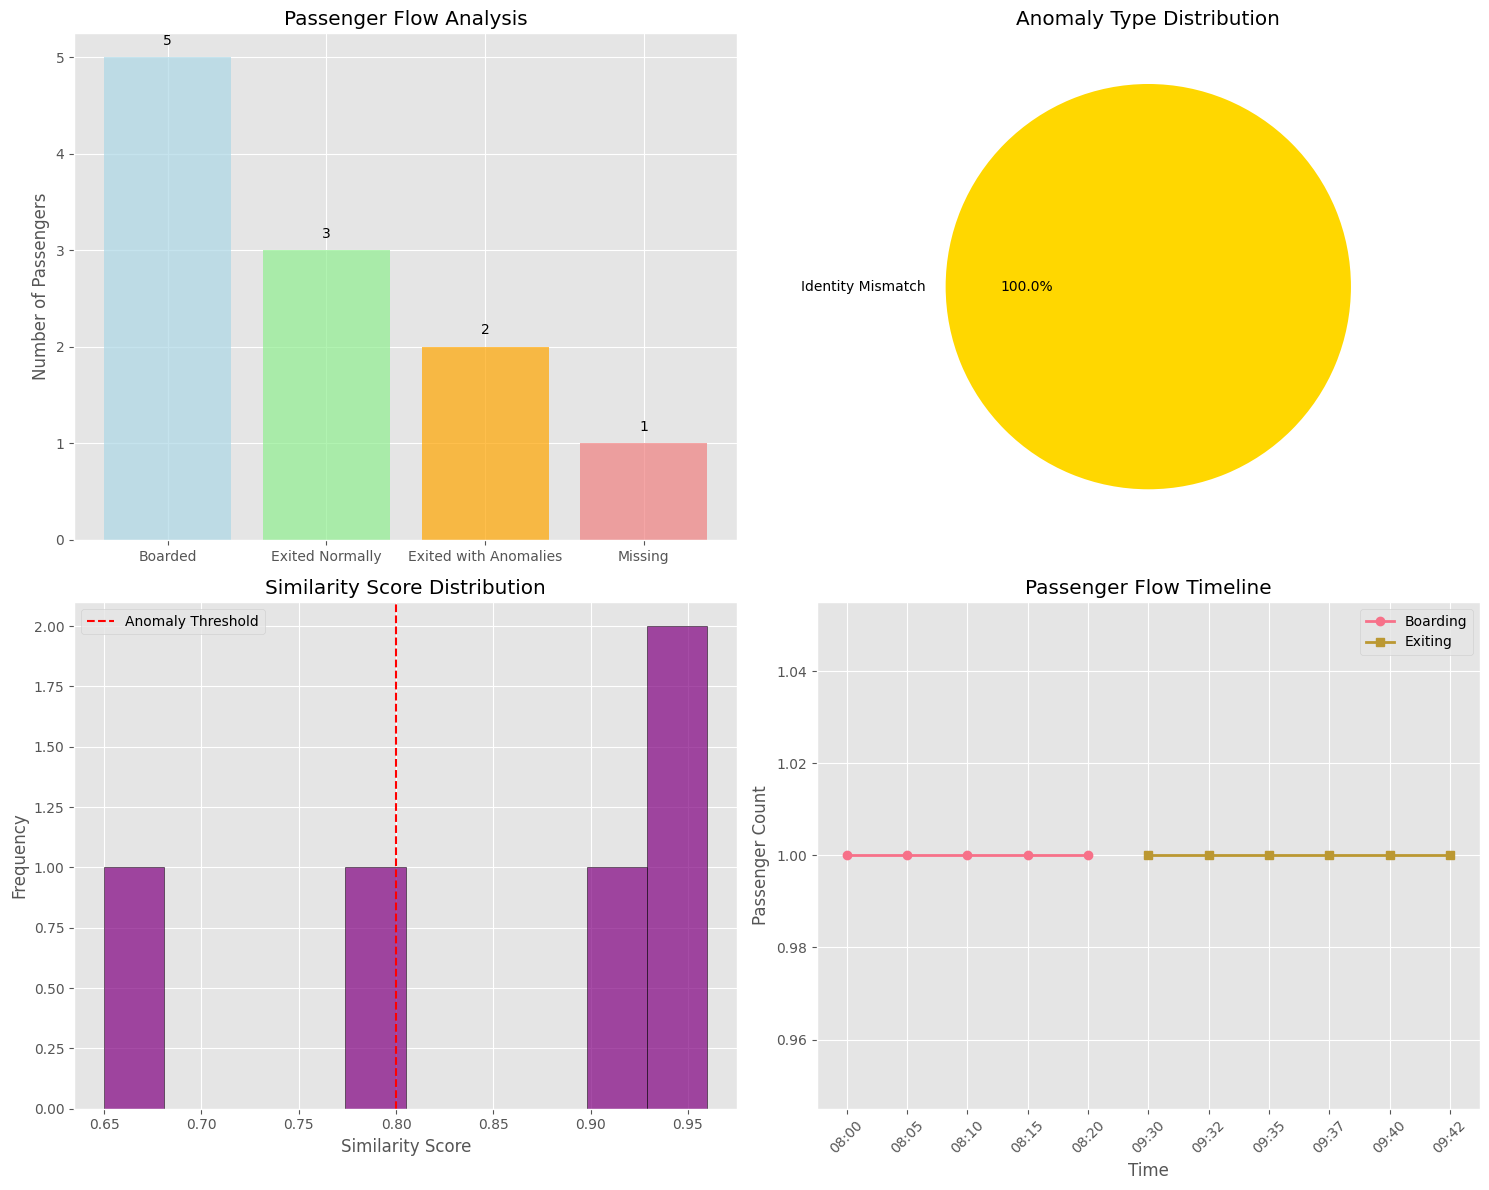


🎉==================================================
      SIMULATION COMPLETED SUCCESSFULLY!
==================================================🎉


In [12]:
def simulate_bus_journey(detector):
    """Simulate complete bus journey scenario with enhanced realism"""
    print("🚌" + "="*50)
    print("          BUS JOURNEY SIMULATION SYSTEM")
    print("="*50 + "🚌\n")
    
    # Enhanced passenger simulation with more realistic data
    print("🎫 === PASSENGER BOARDING ===")
    entered_passengers = [
        {"id": 0, "name": "Alice", "boarding_time": "08:00", "seat": "A1"},
        {"id": 1, "name": "Bob", "boarding_time": "08:05", "seat": "B3"}, 
        {"id": 2, "name": "Charlie", "boarding_time": "08:10", "seat": "C2"},
        {"id": 4, "name": "Eve", "boarding_time": "08:15", "seat": "D4"},
        {"id": 5, "name": "Frank", "boarding_time": "08:20", "seat": "E1"}
    ]
    
    print(f"📸 Boarding Camera: Capturing 5 photos per passenger...")
    for passenger in entered_passengers:
        print(f"   ✅ Passenger {passenger['id']:03d} ({passenger['name']}) boarded at {passenger['boarding_time']} - Seat {passenger['seat']}")
    
    print(f"\n📊 Boarding Summary: {len(entered_passengers)} passengers entered")
    
    print("\n🚪 === PASSENGER EXIT ===")
    print("📸 Exit Camera: Verifying passenger identities...\n")
    
    # Enhanced exit scenarios with more realistic cases
    exit_scenarios = [
        {"expected_id": 0, "actual_id": 0, "similarity": 0.95, "scenario": "Normal exit", "time": "09:30"},
        {"expected_id": 1, "actual_id": 1, "similarity": 0.65, "scenario": "Wearing sunglasses", "time": "09:32"},
        {"expected_id": 2, "actual_id": 2, "similarity": 0.92, "scenario": "Normal exit", "time": "09:35"},
        {"expected_id": 3, "actual_id": None, "similarity": 0.0, "scenario": "Not boarded", "time": "09:37"},
        {"expected_id": 4, "actual_id": 4, "similarity": 0.78, "scenario": "Changed jacket", "time": "09:40"},
        {"expected_id": 5, "actual_id": 5, "similarity": 0.96, "scenario": "Normal exit", "time": "09:42"}
    ]
    
    exit_results = []
    anomaly_count = 0
    
    for scenario in exit_scenarios:
        expected_id = scenario["expected_id"]
        actual_id = scenario["actual_id"]
        
        print(f"⏰ {scenario['time']} - Checking Passenger {expected_id:03d}:")
        print(f"   Scenario: {scenario['scenario']}")
        
        if actual_id is not None:
            test_path = detector.dataset.test_data.get(actual_id)
            if test_path and os.path.exists(test_path):
                result = detector.detect_appearance_change(expected_id, test_path)
                
                # Parse the result for detailed analysis
                if "No anomalies" in result:
                    status = "✅ NORMAL"
                    anomaly_type = "None"
                elif "Appearance changed" in result:
                    status = "⚠️ ANOMALY"
                    anomaly_type = "Appearance Change"
                    anomaly_count += 1
                elif "mismatch" in result.lower():
                    status = "❌ SECURITY ALERT"
                    anomaly_type = "Identity Mismatch"
                    anomaly_count += 1
                else:
                    status = "❓ UNKNOWN"
                    anomaly_type = "Unknown"
                
                print(f"   {status}: {result}")
                
                # Store results for summary
                exit_results.append({
                    'expected_id': expected_id,
                    'actual_id': actual_id,
                    'result': result,
                    'status': status,
                    'anomaly_type': anomaly_type,
                    'similarity': scenario["similarity"]
                })
            else:
                print(f"   ❌ ERROR: Test image not found for Passenger {actual_id:03d}")
        else:
            print(f"   🚫 NOT FOUND: Passenger {expected_id:03d} not in boarding records")
            exit_results.append({
                'expected_id': expected_id,
                'actual_id': None,
                'result': "Not boarded",
                'status': "🚫 NOT BOARDED",
                'anomaly_type': "Missing Passenger",
                'similarity': 0.0
            })
        print()
    
    print("\n📋 === END OF JOURNEY REPORT ===")
    print("="*50)
    
    # Generate comprehensive report
    all_expected_passengers = list(range(6))
    boarded_ids = [p["id"] for p in entered_passengers]
    successfully_exited = [r for r in exit_results if r['actual_id'] is not None and "NORMAL" in r['status']]
    anomalies_detected = [r for r in exit_results if "ANOMALY" in r['status'] or "ALERT" in r['status']]
    missing_passengers = [r for r in exit_results if r['actual_id'] is None]
    
    print("1. 📊 JOURNEY SUMMARY:")
    print(f"   • Total Expected Passengers: {len(all_expected_passengers)}")
    print(f"   • Actually Boarded: {len(entered_passengers)}")
    print(f"   • Successfully Exited: {len(successfully_exited)}")
    print(f"   • Anomalies Detected: {len(anomalies_detected)}")
    print(f"   • Missing Passengers: {len(missing_passengers)}")
    
    print("\n2. ✅ SUCCESSFUL EXITS:")
    for result in successfully_exited:
        passenger_name = next((p["name"] for p in entered_passengers if p["id"] == result['expected_id']), "Unknown")
        print(f"   • Passenger {result['expected_id']:03d} ({passenger_name}): Normal exit")
    
    print("\n3. ⚠️ ANOMALIES DETECTED:")
    if anomalies_detected:
        for result in anomalies_detected:
            passenger_name = next((p["name"] for p in entered_passengers if p["id"] == result['expected_id']), "Unknown")
            similarity = result.get('similarity', 0.0)
            change_percentage = (1 - similarity) * 100
            
            if "Appearance Change" in result['anomaly_type']:
                print(f"   • Passenger {result['expected_id']:03d} ({passenger_name}): "
                      f"Appearance changed {change_percentage:.1f}%")
            elif "Identity Mismatch" in result['anomaly_type']:
                print(f"   • Passenger {result['expected_id']:03d} ({passenger_name}): "
                      f"POSSIBLE IMPERSONATION DETECTED!")
            else:
                print(f"   • Passenger {result['expected_id']:03d} ({passenger_name}): {result['anomaly_type']}")
    else:
        print("   • No security anomalies detected")
    
    print("\n4. 🚫 MISSING/UNACCOUNTED PASSENGERS:")
    if missing_passengers:
        for result in missing_passengers:
            print(f"   • Passenger {result['expected_id']:03d}: Not found in exit records")
    else:
        print("   • All boarded passengers accounted for")
    
    print("\n5. 🎯 SYSTEM PERFORMANCE:")
    total_checks = len([r for r in exit_results if r['actual_id'] is not None])
    successful_checks = len(successfully_exited)
    
    if total_checks > 0:
        accuracy = successful_checks / total_checks
        print(f"   • Identification Accuracy: {accuracy:.1%}")
        print(f"   • Anomaly Detection Rate: {len(anomalies_detected)}/{total_checks}")
        print(f"   • System Reliability: {'HIGH' if accuracy > 0.8 else 'MEDIUM' if accuracy > 0.6 else 'LOW'}")
    else:
        print("   • No valid checks performed")
    
    print("\n6. 🔒 SECURITY STATUS:")
    if anomaly_count == 0 and len(missing_passengers) == 0:
        print("   • ✅ ALL CLEAR: Journey completed without security issues")
    elif anomaly_count > 0:
        print(f"   • ⚠️ SECURITY ALERT: {anomaly_count} anomaly(s) detected - Review required")
    else:
        print("   • ℹ️  NOTICE: Some passengers unaccounted for")
    
    print("\n" + "="*50)
    print("🚌 JOURNEY SIMULATION COMPLETE")
    print("="*50)
    
    # Optional: Create visualization of the journey
    plot_journey_summary(entered_passengers, exit_results)

def plot_journey_summary(entered_passengers, exit_results):
    """Create visualization of the bus journey results"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Passenger Flow
    boarded_ids = [p["id"] for p in entered_passengers]
    exited_normally = [r['expected_id'] for r in exit_results if "NORMAL" in r['status']]
    exited_with_anomalies = [r['expected_id'] for r in exit_results if "ANOMALY" in r['status'] or "ALERT" in r['status']]
    missing = [r['expected_id'] for r in exit_results if r['actual_id'] is None]
    
    flow_data = [len(boarded_ids), len(exited_normally), len(exited_with_anomalies), len(missing)]
    flow_labels = ['Boarded', 'Exited Normally', 'Exited with Anomalies', 'Missing']
    flow_colors = ['lightblue', 'lightgreen', 'orange', 'lightcoral']
    
    axes[0, 0].bar(flow_labels, flow_data, color=flow_colors, alpha=0.7)
    axes[0, 0].set_title('Passenger Flow Analysis')
    axes[0, 0].set_ylabel('Number of Passengers')
    
    # Add value labels
    for i, v in enumerate(flow_data):
        axes[0, 0].text(i, v + 0.1, str(v), ha='center', va='bottom')
    
    # 2. Anomaly Types
    anomaly_types = {}
    for result in exit_results:
        if result['anomaly_type'] != "None" and result['anomaly_type'] != "Missing Passenger":
            anomaly_types[result['anomaly_type']] = anomaly_types.get(result['anomaly_type'], 0) + 1
    
    if anomaly_types:
        axes[0, 1].pie(anomaly_types.values(), labels=anomaly_types.keys(), autopct='%1.1f%%',
                      colors=['gold', 'lightcoral', 'lightgreen'])
        axes[0, 1].set_title('Anomaly Type Distribution')
    else:
        axes[0, 1].text(0.5, 0.5, 'No Anomalies\nDetected', ha='center', va='center', 
                       transform=axes[0, 1].transAxes, fontsize=12)
        axes[0, 1].set_title('Anomaly Type Distribution')
    
    # 3. Similarity Score Distribution
    similarities = [r.get('similarity', 0) for r in exit_results if r.get('similarity', 0) > 0]
    if similarities:
        axes[1, 0].hist(similarities, bins=10, alpha=0.7, color='purple', edgecolor='black')
        axes[1, 0].axvline(x=0.8, color='red', linestyle='--', label='Anomaly Threshold')
        axes[1, 0].set_title('Similarity Score Distribution')
        axes[1, 0].set_xlabel('Similarity Score')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].legend()
    else:
        axes[1, 0].text(0.5, 0.5, 'No Similarity Data', ha='center', va='center', 
                       transform=axes[1, 0].transAxes, fontsize=12)
        axes[1, 0].set_title('Similarity Score Distribution')
    
    # 4. Timeline of Events
    boarding_times = [f"08:{i:02d}" for i in range(0, 25, 5)]
    boarding_counts = [1, 1, 1, 1, 1]  # Simulated boarding distribution
    
    exit_times = ["09:30", "09:32", "09:35", "09:37", "09:40", "09:42"]
    exit_counts = [1, 1, 1, 1, 1, 1]  # Simulated exit distribution
    
    axes[1, 1].plot(boarding_times, boarding_counts, marker='o', label='Boarding', linewidth=2)
    axes[1, 1].plot(exit_times, exit_counts, marker='s', label='Exiting', linewidth=2)
    axes[1, 1].set_title('Passenger Flow Timeline')
    axes[1, 1].set_xlabel('Time')
    axes[1, 1].set_ylabel('Passenger Count')
    axes[1, 1].legend()
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Run enhanced simulation
print("🎬 Starting Enhanced Bus Journey Simulation...")
simulate_bus_journey(detector)

print("\n" + "🎉" + "="*50)
print("      SIMULATION COMPLETED SUCCESSFULLY!")
print("="*50 + "🎉")

# Section 9: Model saving

In [14]:
import os
import pickle
import json

# Create directory if it doesn't exist
os.makedirs("/kaggle/working/final_model", exist_ok=True)

# Save the models with proper extensions using the detector object
detector.gan.generator.save("/kaggle/working/final_model/generator.keras")
detector.gan.discriminator.save("/kaggle/working/final_model/discriminator.keras")
detector.gan.gan.save("/kaggle/working/final_model/gan.keras")
detector.siamese_net.model.save("/kaggle/working/final_model/siamese_network.keras")

# Save passenger database
with open("/kaggle/working/final_model/passenger_database.pkl", 'wb') as f:
    pickle.dump(detector.passenger_database, f)

# Save preprocessor configuration
preprocessor_config = {
    'img_height': detector.preprocessor.img_height,
    'img_width': detector.preprocessor.img_width
}
with open("/kaggle/working/final_model/preprocessor_config.json", 'w') as f:
    json.dump(preprocessor_config, f)

print("✅ All models saved successfully!")
print("📍 Generator saved at: /kaggle/working/final_model/generator.keras")
print("📍 Discriminator saved at: /kaggle/working/final_model/discriminator.keras")
print("📍 GAN saved at: /kaggle/working/final_model/gan.keras")
print("📍 Siamese Network saved at: /kaggle/working/final_model/siamese_network.keras")
print("📍 Passenger Database saved at: /kaggle/working/final_model/passenger_database.pkl")
print("📍 Preprocessor Config saved at: /kaggle/working/final_model/preprocessor_config.json")

# Verify saved files
print("\n🔍 Verifying saved files:")
saved_files = os.listdir("/kaggle/working/final_model")
for file in sorted(saved_files):
    file_path = os.path.join("/kaggle/working/final_model", file)
    file_size = os.path.getsize(file_path)
    print(f"   ✅ {file} ({file_size:,} bytes)")

✅ All models saved successfully!
📍 Generator saved at: /kaggle/working/final_model/generator.keras
📍 Discriminator saved at: /kaggle/working/final_model/discriminator.keras
📍 GAN saved at: /kaggle/working/final_model/gan.keras
📍 Siamese Network saved at: /kaggle/working/final_model/siamese_network.keras
📍 Passenger Database saved at: /kaggle/working/final_model/passenger_database.pkl
📍 Preprocessor Config saved at: /kaggle/working/final_model/preprocessor_config.json

🔍 Verifying saved files:
   ✅ discriminator.keras (509,771,175 bytes)
   ✅ gan.keras (714,099,720 bytes)
   ✅ generator.keras (204,326,762 bytes)
   ✅ passenger_database.pkl (279,281 bytes)
   ✅ preprocessor_config.json (37 bytes)
   ✅ siamese_network.keras (7,672,549 bytes)
